# Energy Sector Investment Analysis: A Data-Driven Approach
## Empirical Study of Global Energy Equities Using 26 Years of Market Data (Jan 2000 – Mar 2026)

---

**Research Framework:**

| Section | Title | Objective |
|:--:|:-----|:---------|
| **Part 1** | Market Structure & Correlation | วิเคราะห์โครงสร้างความสัมพันธ์ระหว่างสินทรัพย์พลังงาน |
| **Part 2** | Macroeconomic Drivers | ศึกษาตัวแปรมหภาคที่กำหนดทิศทางราคาหุ้นพลังงาน |
| **Part 3** | Crisis Analysis & Volatility Regime | จำแนกรูปแบบความเสี่ยงในแต่ละช่วงวิกฤต |
| **Part 4** | Comparative Performance & Event Studies | เปรียบเทียบผลตอบแทนเชิงเปรียบเทียบ US vs Thai |
| **Part 5** | Strategic Allocation Framework | สังเคราะห์ผลวิเคราะห์สู่กรอบการจัดสรรการลงทุน |

> **Research Thesis:** หุ้นพลังงานเป็นสินทรัพย์ที่มีลักษณะเฉพาะตัว (Idiosyncratic Characteristics) ซึ่งต้องอาศัยการวิเคราะห์เชิงปริมาณหลายมิติ — ทั้งด้าน Correlation Structure, Macro Sensitivity, Crisis Beta, และ Risk-Adjusted Return — เพื่อออกแบบกลยุทธ์การจัดสรรที่เหมาะสม

---
*Data Source: Yahoo Finance (Weekly Prices) & Federal Reserve Economic Data (FRED)*


In [21]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
%matplotlib inline

# ── File Paths ──
CLEANED_FILE = "data/cleaned/energy_macro_cleaned.xlsx"
if not os.path.exists(CLEANED_FILE):
    _alt = os.path.join(os.path.expanduser("~"), "Downloads",
                        "data", "cleaned", "energy_macro_cleaned.xlsx")
    if os.path.exists(_alt):
        CLEANED_FILE = _alt
        print(f"Using fallback path: {CLEANED_FILE}")

FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ── Color Palette ──
C_RED    = "#D32F2F"
C_GREEN  = "#388E3C"
C_BLUE   = "#1565C0"
C_ORANGE = "#EF6C00"
C_GREY   = "#9E9E9E"
C_DARK   = "#212121"
C_OIL    = "#795548"
C_GOLD   = "#F9A825"
SOURCE_TEXT = "Source: Yahoo Finance & FRED"

US_TICKERS = ["XOM", "CVX", "COP", "SHEL", "TTE"]
TH_TICKERS = ["PTT.BK", "PTTEP.BK", "PTG.BK", "BCP.BK", "PTTGC.BK"]
ALL_STOCKS = US_TICKERS + TH_TICKERS

# ── Style Function ──
def style_ax(ax, title="", subtitle="", caption="", fig_num=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(C_GREY)
    ax.spines["bottom"].set_color(C_GREY)
    ax.tick_params(colors=C_DARK, labelsize=9)
    ax.yaxis.grid(True, alpha=0.25, color=C_GREY, linestyle="--")
    ax.set_axisbelow(True)
    full_title = f"Fig {fig_num}. {title}" if fig_num else title
    ax.set_title(full_title, fontsize=13, fontweight="bold", color=C_DARK, loc="left", pad=12)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=9, color=C_GREY, va="bottom")
    if caption:
        ax.annotate(caption, xy=(0, -0.13), xycoords="axes fraction",
                    fontsize=7.5, color=C_DARK, style="italic", wrap=True)
    ax.annotate(SOURCE_TEXT, xy=(1, -0.13), xycoords="axes fraction",
                fontsize=7, color=C_GREY, ha="right")

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white", transparent=False)
    print(f"  Saved: {path}")

def pivot_close(stocks, tickers):
    sub = stocks[stocks["Ticker"].isin(tickers)][["Close", "Ticker"]].copy()
    pivoted = sub.pivot_table(index=sub.index, columns="Ticker", values="Close")
    return pivoted.sort_index().ffill()

def pivot_indexed(stocks, tickers):
    sub = stocks[stocks["Ticker"].isin(tickers)][["Indexed_Price", "Ticker"]].copy()
    pivoted = sub.pivot_table(index=sub.index, columns="Ticker", values="Indexed_Price")
    return pivoted.sort_index().ffill()

print("✅ Setup Complete")


✅ Setup Complete


In [22]:
stocks = pd.read_excel(CLEANED_FILE, sheet_name="Stocks_Master", index_col=0, parse_dates=True)
fred = pd.read_excel(CLEANED_FILE, sheet_name="FRED_Macro", index_col=0, parse_dates=True)
spread = pd.read_excel(CLEANED_FILE, sheet_name="Upstream_Downstream", index_col=0, parse_dates=True)
print(f"📊 Loaded: {len(stocks):,} stock rows | {len(fred):,} FRED macro rows")
print(f"📅 Date Range: {stocks.index.min().date()} → {stocks.index.max().date()}")
print(f"🏢 Tickers: {stocks['Ticker'].nunique()} assets")


📊 Loaded: 14,559 stock rows | 1,367 FRED macro rows
📅 Date Range: 2000-01-01 → 2026-03-09
🏢 Tickers: 12 assets


---
# Part 1: Market Structure & Correlation Analysis
### การวิเคราะห์โครงสร้างตลาดและความสัมพันธ์ระหว่างสินทรัพย์พลังงาน

ก่อนที่จะวิเคราะห์ผลตอบแทนหรือออกแบบกลยุทธ์ใดๆ สิ่งแรกที่ต้องทำความเข้าใจคือ **โครงสร้างความสัมพันธ์** (Correlation Structure) ระหว่างสินทรัพย์พลังงาน ส่วนนี้จะนำเสนอข้อค้นพบ 3 ประการ ได้แก่ แผนที่ Correlation Matrix ระหว่างสินทรัพย์ การจัดอันดับความไวต่อราคาน้ำมัน (Oil Price Sensitivity) และพลวัตของ Spread ระหว่าง Brent กับ WTI


### Fig 1. Correlation Matrix — โครงสร้างความสัมพันธ์ระหว่างสินทรัพย์พลังงาน



[Fig 1] Strategic Asset Correlation Matrix
  Saved: outputs/figures\01_correlation_matrix.png


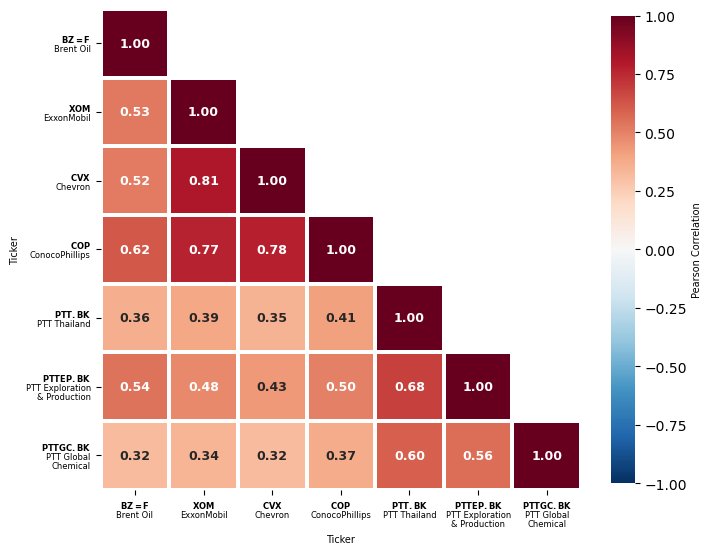

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def fig_01_correlation_matrix(stocks):

    print("\n[Fig 1] Strategic Asset Correlation Matrix")

    df = stocks.copy()

    if 'Date' not in df.columns and df.index.name == 'Date':
        df = df.reset_index()
    elif 'Date' not in df.columns:
        raise KeyError("ไม่พบคอลัมน์ 'Date'")

    df['Date'] = pd.to_datetime(df['Date'])

    df['Aligned_Date'] = df['Date'] + pd.to_timedelta(
        (7 - df['Date'].dt.dayofweek) % 7, unit='D'
    )

    ordered_tickers = ["BZ=F","XOM","CVX","COP","PTT.BK","PTTEP.BK","PTTGC.BK"]

    close_wide = df.pivot_table(
        index='Aligned_Date',
        columns='Ticker',
        values='Close',
        aggfunc='mean'
    )

    valid_tickers = [t for t in ordered_tickers if t in close_wide.columns]
    close_wide = close_wide[valid_tickers]

    weekly_rets = close_wide.pct_change().dropna()

    corr = weekly_rets.corr().round(2)

    fig, ax = plt.subplots(figsize=(7,6), dpi=100)

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    hm = sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        ax=ax,
        linewidths=1.5,
        vmin=-1,
        vmax=1,
        cbar_kws={
            "label": "Pearson Correlation",
            "shrink": 0.84
        },
        annot_kws={"size": 9, "weight": "bold"}
    )
    # ✅ แกนซ้าย (Ticker)
    ax.set_ylabel("Ticker", fontsize=7)
    
    # ✅ แกนล่าง (Ticker)
    ax.set_xlabel("Ticker", fontsize=7)
    
    # ✅ Colorbar (Pearson Correlation)
    cbar = hm.collections[0].colorbar
    cbar.set_label("Pearson Correlation", fontsize=7)

    # ===== Company names =====
    company_names = {
        "BZ=F": "Brent Oil",
        "XOM": "ExxonMobil",
        "CVX": "Chevron",
        "COP": "ConocoPhillips",
        "PTT.BK": "PTT Thailand",
        "PTTEP.BK": "PTT Exploration\n& Production",
        "PTTGC.BK": "PTT Global\nChemical"
    }
    
    labels = [f"$\\bf{{{t}}}$\n{company_names.get(t,'')}" for t in valid_tickers]
    
    ax.set_xticklabels(labels, rotation=0, ha="center", fontsize=6)
    ax.set_yticklabels(labels, rotation=0, fontsize=6)
    
    # ทำให้บรรทัด company ดูเล็กลง
    for label in ax.get_xticklabels():
        label.set_linespacing(1)

    for label in ax.get_yticklabels():
        label.set_linespacing(1)

    plt.tight_layout(pad=0.1)

    save_fig(fig, "01_correlation_matrix")

    plt.show()


fig_01_correlation_matrix(stocks)

#### การวิเคราะห์ Fig 1: Correlation Structure ของสินทรัพย์พลังงาน

Correlation Matrix ที่คำนวณจาก Weekly Returns ตลอด 26 ปี เผยให้เห็นโครงสร้างความสัมพันธ์ที่สำคัญ 3 ประการ ประการแรก หุ้นพลังงานสหรัฐฯ (XOM, CVX, COP) มี Intra-group Correlation สูงมาก (r > 0.7) แสดงว่าหุ้นกลุ่มนี้เคลื่อนไหวเป็นกลุ่มก้อน (Cluster) การถือหุ้น US Energy หลายตัวพร้อมกันจึงไม่ได้ให้ Diversification Benefit ที่แท้จริง

ประการที่สอง Correlation ระหว่างกลุ่ม US กับกลุ่ม Thai อยู่ที่ระดับปานกลาง (~0.45) ซึ่งเกิดจากความแตกต่างด้านโครงสร้างตลาดทุน อัตราแลกเปลี่ยน นโยบายการควบคุมราคาภายในประเทศ และสัดส่วนธุรกิจ Upstream-Downstream ที่ต่างกัน ความแตกต่างนี้ชี้ให้เห็นว่าการจัดสรรข้ามประเทศ (Cross-country Allocation) ให้ประโยชน์ด้านการกระจายความเสี่ยงได้ดีกว่าการจัดสรรภายในประเทศเดียว

ประการที่สาม Brent Crude ทำหน้าที่เป็น Central Node ที่มี Correlation บวกกับทุกสินทรัพย์ในระบบ แสดงว่าราคาน้ำมันคือตัวแปรหลัก (Dominant Factor) ที่ขับเคลื่อนทั้งระบบ อย่างไรก็ตาม ค่า Correlation ไม่คงที่ตลอดเวลา — งานวิจัยด้าน Dynamic Conditional Correlation (DCC) ชี้ว่า Correlation มักพุ่งสูงขึ้นในช่วงวิกฤต ซึ่งเป็นช่วงที่ Diversification Benefit ลดลงพอดี

**Key Findings:**
- การกระจายความเสี่ยงที่มีประสิทธิภาพต้องใช้การจัดสรรข้ามประเทศ (US + TH) ไม่ใช่ข้ามตัวภายในประเทศเดียว
- Brent Crude เป็น Systematic Risk Factor หลักของระบบ ผู้ลงทุนควรติดตามราคาน้ำมันเป็นลำดับแรก
- Correlation ที่สูงขึ้นในช่วงวิกฤต (Correlation Breakdown) เป็นความเสี่ยงที่ต้องคำนึงในการทำ Stress Testing


### Fig 2. Oil Price Sensitivity — การจัดอันดับความไวต่อราคาน้ำมัน



[Fig 2] Oil-Stock Sensitivity Ranking
  Saved: outputs/figures\02_oil_stock_correlation.png


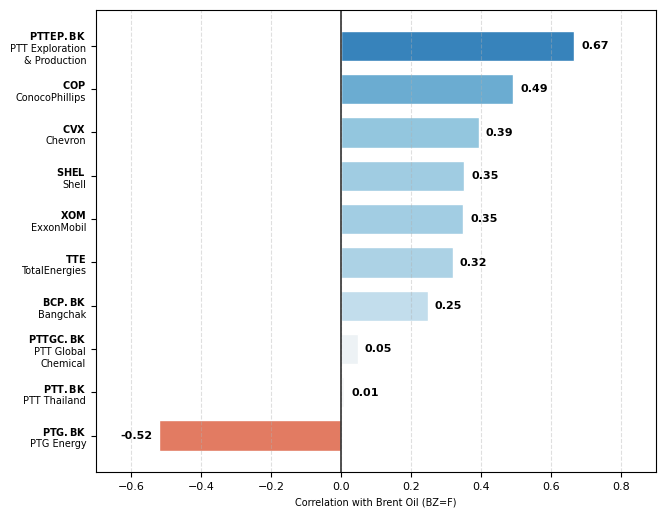

In [24]:
def fig_02_oil_sensitivity(stocks, fred):

    print("\n[Fig 2] Oil-Stock Sensitivity Ranking")

    oil = pivot_close(stocks, ["BZ=F"])
    stk = pivot_close(stocks, ALL_STOCKS)

    merged = oil.join(stk, how="outer").sort_index().ffill().dropna()

    corr = merged.corr()["BZ=F"].drop("BZ=F").sort_values(ascending=True)

    # ===== Company names =====
    company_names = {
        'XOM': 'ExxonMobil',
        'CVX': 'Chevron',
        'COP': 'ConocoPhillips',
        'SHEL': 'Shell',
        'TTE': 'TotalEnergies',
        'PTT.BK': 'PTT Thailand',
        'PTTEP.BK': 'PTT Exploration\n& Production',
        'PTTGC.BK': 'PTT Global\nChemical',
        'BCP.BK': 'Bangchak',
        'PTG.BK': 'PTG Energy'
    }

    # ✅ ห้ามมี \large เด็ดขาด
    plot_labels = [
        f"$\\bf{{{t}}}$\n{company_names.get(t,'')}"
        for t in corr.index
    ]

    fig, ax = plt.subplots(figsize=(7,6), dpi=100)

    cmap = plt.get_cmap("RdBu")
    norm = plt.Normalize(-1, 1)
    colors = cmap(norm(corr.values))

    bars = ax.barh(
        plot_labels,
        corr.values,
        color=colors,
        edgecolor="white",
        height=0.7
    )

    ax.set_xlim(-0.7, 0.9)
    ax.axvline(0, color='#333333', lw=1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

    # ===== Value labels =====
    for bar, val in zip(bars, corr.values):

        if val >= 0:
            xpos = min(val + 0.02, 0.9)
            ha = "left"
        else:
            xpos = max(val - 0.02, -0.9)
            ha = "right"

        ax.text(
            xpos,
            bar.get_y() + bar.get_height()/2,
            f"{val:.2f}",
            va="center",
            ha=ha,
            fontsize=8,
            fontweight="bold"
        )

    # ✅ ลดขนาดฟ้อนต์
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=8)

    ax.set_xlabel("Correlation with Brent Oil (BZ=F)", fontsize=7)

    # 🔥🔥 เพิ่มพื้นที่ซ้าย (สำคัญมาก)
    plt.subplots_adjust(left=0.1)

    # หรือใช้ตัวนี้แทนก็ได้ (เลือกอย่างใดอย่างหนึ่ง)
    # plt.tight_layout(rect=[0.25, 0, 1, 1])

    save_fig(fig, "02_oil_stock_correlation")
    plt.show()


fig_02_oil_sensitivity(stocks, fred)

#### การวิเคราะห์ Fig 2: Oil Sensitivity Spectrum ของหุ้นพลังงาน

Horizontal Bar Chart นี้จัดอันดับค่า Correlation ของราคาปิดรายสัปดาห์ระหว่างหุ้นพลังงานแต่ละตัวกับ Brent Crude (BZ=F) ผลลัพธ์แสดง Spectrum ที่ชัดเจน — หุ้น Upstream อย่าง ConocoPhillips (COP) และ PTTEP มีค่า Correlation สูงสุด เนื่องจากรายได้ผูกติดกับราคาน้ำมันโดยตรง (Revenue = Production Volume x Oil Price) ในทางตรงข้าม หุ้น Downstream Retail อย่าง PTG Energy มีค่า Correlation ต่ำสุด เพราะธุรกิจปั๊มน้ำมันมี Margin ที่ค่อนข้างคงที่ และราคาขายปลีกในประเทศไทยอยู่ภายใต้กลไกการอุดหนุนของกองทุนน้ำมันเชื้อเพลิง

ความแตกต่างนี้มีนัยสำคัญในเชิงกลยุทธ์ — หุ้น Upstream สามารถใช้เป็น Directional Bet ต่อทิศทางราคาน้ำมันได้ (Proxy for Oil Exposure) ขณะที่หุ้น Downstream ให้ผลตอบแทนที่ไม่ไวต่อราคาน้ำมันมากนัก จึงเหมาะเป็นส่วนประกอบที่ให้ Stability ในพอร์ตการลงทุน การจำแนก Oil Sensitivity นี้เทียบเคียงได้กับแนวคิด Factor Loading ใน Multi-Factor Model ซึ่ง Oil Factor เป็นปัจจัยที่มีอิทธิพลสูงสุดในกลุ่มพลังงาน

**Key Findings:**
- Upstream (COP, PTTEP) = High Oil-Beta → เหมาะสำหรับ Tactical Allocation เมื่อมีมุมมองเชิงบวกต่อราคาน้ำมัน
- Downstream (PTG, BCP) = Low Oil-Beta → เหมาะเป็นส่วนประกอบเชิงป้องกัน (Defensive Component) ในพอร์ต
- การจำแนก Oil Sensitivity ช่วยให้ผู้ลงทุนสามารถปรับระดับ Oil Exposure ของพอร์ตได้ตามมุมมอง (View-Based Allocation)


### Fig 3. Brent-WTI Spread — พลวัตของตลาดน้ำมันระดับโลก



[Fig 3] Brent-WTI Strategic Spread
   Date range: 2007-07-30 → 2026-03-02
   Rows: 970 | Avg Spread: $5.32
  Saved: outputs/figures\03_brent_wti_spread.png


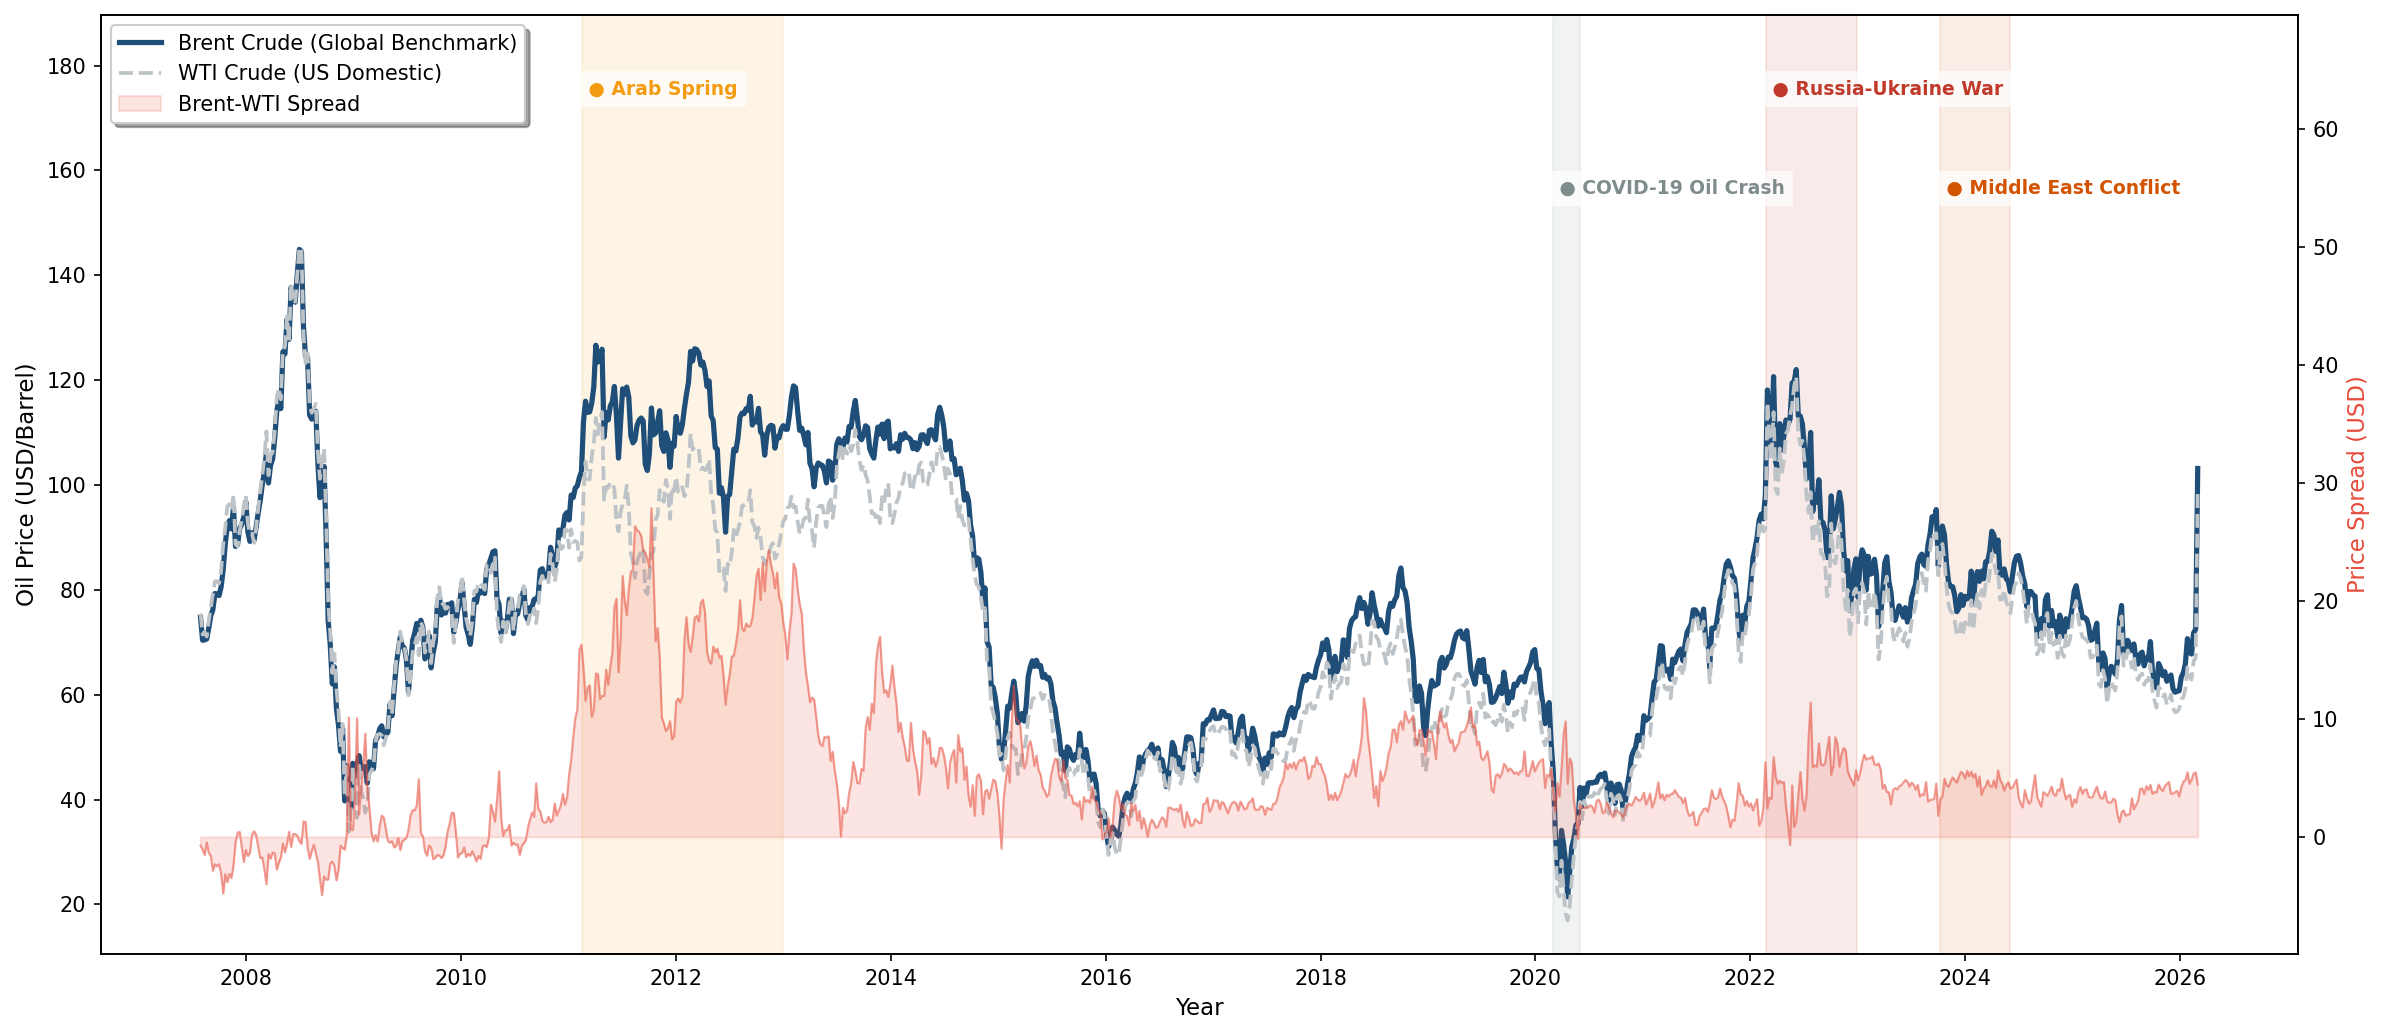

In [25]:
def fig_03_brent_wti_spread(stocks_df):
    print("\n[Fig 3] Brent-WTI Strategic Spread")

    try:
        # ── FIX: reset_index เพื่อให้มีคอลัมน์ 'Date' สำหรับ pivot ──
        df = stocks_df.copy()
        if 'Date' not in df.columns:
            df = df.reset_index()           # Date กลับมาเป็น column
        df['Date'] = pd.to_datetime(df['Date'])

        tickers = ["BZ=F", "CL=F"]
        sub = df[df['Ticker'].isin(tickers)]

        # ใช้ pivot_table แทน pivot เพื่อรองรับ duplicate dates
        prices = sub.pivot_table(index='Date', columns='Ticker', values='Close', aggfunc='mean')

        # ── ตรวจสอบว่ามี Ticker ครบ ──
        missing = [t for t in tickers if t not in prices.columns]
        if missing:
            print(f"⚠️ Missing tickers in data: {missing}")
            print(f"   Available tickers: {df['Ticker'].unique()[:15]}")
            return

        prices.columns = ['Brent', 'WTI']
        prices = prices.sort_index().dropna()
        prices['Spread'] = prices['Brent'] - prices['WTI']

        print(f"   Date range: {prices.index.min().date()} → {prices.index.max().date()}")
        print(f"   Rows: {len(prices):,} | Avg Spread: ${prices['Spread'].mean():.2f}")

        fig, ax1 = plt.subplots(figsize=(16, 7), dpi=150)

        # ── แกนซ้าย: ราคาจริง ──
        ln1 = ax1.plot(prices.index, prices['Brent'], color='#1F4E79', lw=2.5,
                       label="Brent Crude (Global Benchmark)")
        ln2 = ax1.plot(prices.index, prices['WTI'], color='#BDC3C7', lw=1.8, ls='--',
                       label="WTI Crude (US Domestic)")
        ax1.set_ylabel("Oil Price (USD/Barrel)", fontsize=11)
        ax1.set_ylim(ax1.get_ylim()[0], ax1.get_ylim()[1] * 1.25)

        # ── แกนขวา: Spread ──
        ax2 = ax1.twinx()
        ax2.fill_between(prices.index, 0, prices['Spread'],
                         color='#E74C3C', alpha=0.15, label="Brent-WTI Spread")
        ax2.plot(prices.index, prices['Spread'], color='#E74C3C', lw=1, alpha=0.5)
        ax2.set_ylabel("Price Spread (USD)", color='#E74C3C', fontsize=11)
        ax2.set_ylim(prices['Spread'].min() - 5, prices['Spread'].max() * 2.5)
        ax1.set_xlabel("Year", fontsize=11)  

        # ── Crisis Zones ──
        crisis_zones = [
            ("2011-02-15", "2012-12-30", "Arab Spring", "#F39C12", 0.92),
            ("2020-03-01", "2020-06-01", "COVID-19 Oil Crash", "#7F8C8D", 0.82),
            ("2022-02-24", "2022-12-31", "Russia-Ukraine War", "#C0392B", 0.92),
            ("2023-10-07", "2024-06-01", "Middle East Conflict", "#D35400", 0.82)
        ]
        for start, end, label, color, v_pos in crisis_zones:
            s, e = pd.to_datetime(start), pd.to_datetime(end)
            if s >= prices.index.min() and s <= prices.index.max():
                ax1.axvspan(s, e, color=color, alpha=0.1, zorder=1)
                ax1.text(s, ax1.get_ylim()[1] * v_pos, f" ● {label}", color=color,
                         fontsize=9, fontweight='bold',
                         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # ── Legend ──
        lines = ln1 + ln2
        labels_leg = [l.get_label() for l in lines] + ["Brent-WTI Spread"]
        ax1.legend(lines + [plt.Rectangle((0,0),1,1, color='#E74C3C', alpha=0.15)],
                   labels_leg, loc="upper left", frameon=True, shadow=True)


        plt.tight_layout()
        save_fig(fig, "03_brent_wti_spread")
        plt.show()

    except Exception as e:
        import traceback
        print(f"❌ Error in Fig 3: {e}")
        traceback.print_exc()

fig_03_brent_wti_spread(stocks)


#### การวิเคราะห์ Fig 3: Brent-WTI Spread ในฐานะ Supply Stress Indicator

Brent Crude (ราคาอ้างอิงระดับโลก ซื้อขายที่ ICE London) และ WTI (ราคาอ้างอิงของสหรัฐฯ ส่งมอบที่ Cushing, Oklahoma) มีราคาที่เคลื่อนไหวในทิศทางเดียวกันโดยพื้นฐาน แต่ส่วนต่าง (Spread) ระหว่างทั้งสองสะท้อนดุลอุปสงค์-อุปทานระดับภูมิภาค (Regional Supply-Demand Balance) กราฟนี้แสดง Time Series ของทั้งสองราคาพร้อมกับ Spread Area ซึ่ง Overlay ด้วยช่วงเวลาวิกฤตด้านภูมิรัฐศาสตร์

ข้อสังเกตหลักคือ Spread มักขยายตัวอย่างรวดเร็วเมื่อเกิด Supply Disruption ระดับโลก เช่น Arab Spring (2011), สงครามรัสเซีย-ยูเครน (2022) และความขัดแย้งตะวันออกกลาง เนื่องจาก Brent สะท้อนราคาน้ำมันที่ขนส่งทางทะเล (Seaborne Crude) ซึ่งได้รับผลกระทบจากปัญหาด้าน Supply มากกว่า WTI ที่มี Shale Oil เป็นแหล่งผลิตภายในประเทศ การขยายตัวของ Spread จึงเป็น Leading Indicator สำหรับ Supply Tightness ในตลาดโลก

กรณีพิเศษคือ COVID-19 (มี.ค. 2020) ที่ WTI ราคาติดลบเป็นครั้งแรกในประวัติศาสตร์ สาเหตุมาจาก Storage Constraint ที่ Cushing เนื่องจาก Demand Shock ทำให้ปริมาณน้ำมันในถังเก็บเต็มจนล้น เหตุการณ์นี้เป็นตัวอย่างของ Contango Extreme ที่แสดงว่าแม้แต่สินค้าโภคภัณฑ์ก็มี Physical Constraint ที่กำหนดราคาได้

**Key Findings:**
- Spread > $10 มักเป็น Leading Signal ว่าหุ้น Upstream กำลังจะปรับตัวขึ้นตาม Supply Premium
- Spread ที่แคบลง (Convergence) บ่งชี้ว่าตลาดกลับสู่ดุลยภาพ → Downstream มักได้เปรียบในช่วงนี้เพราะ Refining Margin คงที่
- การติดตาม Spread Dynamics เป็นเครื่องมือเสริมที่มีคุณค่าสำหรับ Tactical Timing ในกลุ่มพลังงาน


---
# Part 2: Macroeconomic Drivers
### การศึกษาตัวแปรมหภาคที่กำหนดทิศทางราคาหุ้นพลังงาน

ราคาหุ้นพลังงานไม่ได้ถูกกำหนดโดยอุปสงค์-อุปทานน้ำมันเพียงอย่างเดียว ส่วนนี้จะวิเคราะห์ตัวแปรมหภาค 3 ตัวที่มีอิทธิพลสำคัญ ได้แก่ ดัชนีเงินเฟ้อพลังงาน (Energy CPI) ดัชนีค่าเงินดอลลาร์สหรัฐ (Trade-Weighted USD Index) และดัชนีผลผลิตอุตสาหกรรม (Industrial Production Index) ผ่านการเปรียบเทียบเชิงบรรทัดฐาน (Normalized Comparison) กับผลตอบแทนหุ้นพลังงาน


### Fig 4. Inflation Hedge Hypothesis — หุ้นพลังงานเป็นเกราะป้องกันเงินเฟ้อหรือไม่?



[Fig 4] Energy Inflation Hedge Analysis
  Saved: outputs/figures\04_inflation_hedge.png


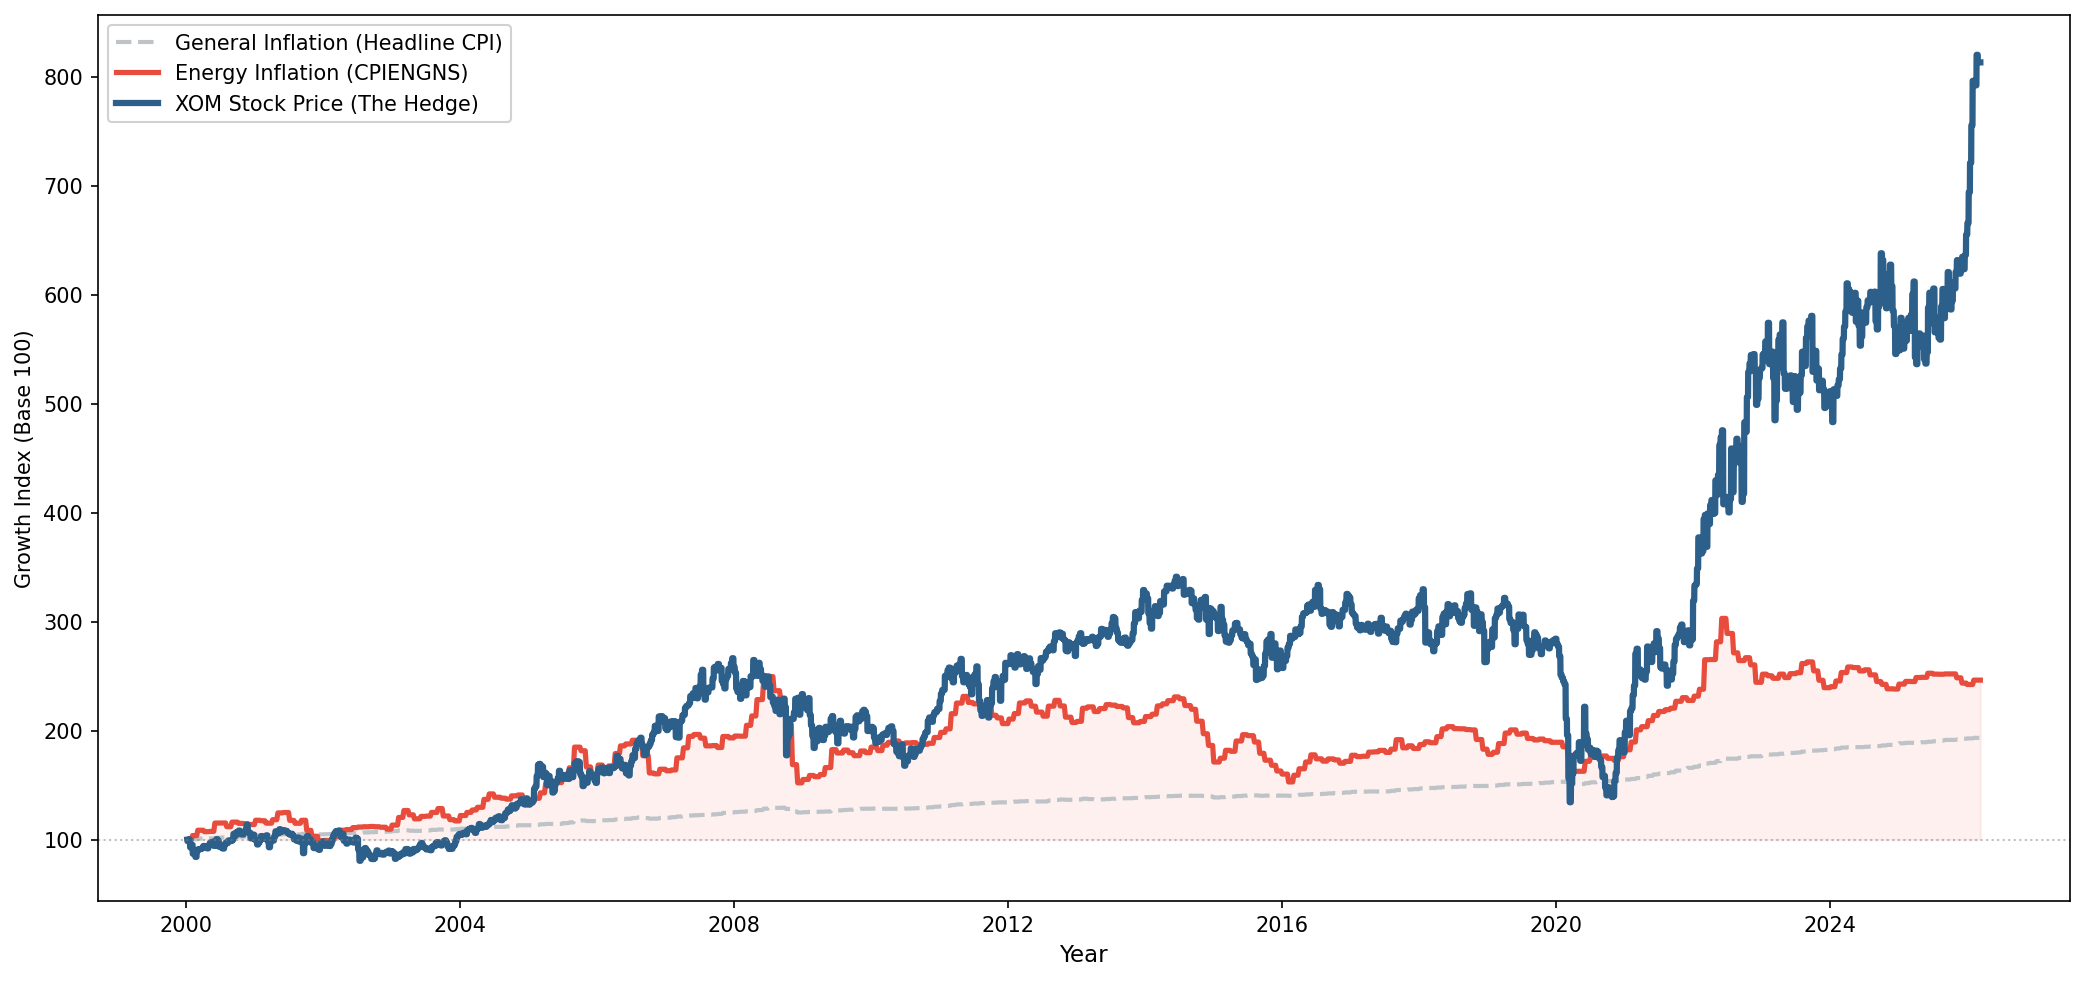

In [26]:
def fig_04_inflation_hedge(stocks, fred):
    print("\n[Fig 4] Energy Inflation Hedge Analysis")
    def safe_prepare(df):
        df_copy = df.copy()
        if 'Date' in df_copy.columns:
            df_copy['Date'] = pd.to_datetime(df_copy['Date'])
            df_copy = df_copy.set_index('Date')
        return df_copy
    try:
        fred_proc = safe_prepare(fred)
        cpi_data = fred_proc[["CPIENGNS", "CPIAUCSL"]].dropna()
        xom_raw = stocks[stocks['Ticker'] == 'XOM'].copy()
        xom_proc = safe_prepare(xom_raw)
        xom_close = xom_proc[['Close']]
        if isinstance(xom_close.columns, pd.MultiIndex):
            xom_close.columns = xom_close.columns.get_level_values(0)
        merged_raw = cpi_data.join(xom_close, how="outer").sort_index().ffill().dropna()
        merged_raw.columns = ['Energy_CPI', 'Headline_CPI', 'XOM_Price']
        if merged_raw.empty: return
        merged = (merged_raw / merged_raw.iloc[0]) * 100
        fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
        ax.fill_between(merged.index, 100, merged["Energy_CPI"], alpha=0.08, color='#E74C3C')
        ax.plot(merged.index, merged["Headline_CPI"], color='#BDC3C7', lw=2, ls='--', label="General Inflation (Headline CPI)")
        ax.plot(merged.index, merged["Energy_CPI"], color='#E74C3C', lw=2.5, label="Energy Inflation (CPIENGNS)")
        ax.plot(merged.index, merged["XOM_Price"], color='#2C5F8A', lw=3, label="XOM Stock Price (The Hedge)")
        ax.axhline(100, color='grey', ls=':', lw=1, alpha=0.5)
        ax.set_ylabel("Growth Index (Base 100)")
        ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9)
        ax.set_xlabel("Year", fontsize=11)  
        
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "04_inflation_hedge")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_04_inflation_hedge(stocks, fred)


#### การวิเคราะห์ Fig 4: การทดสอบสมมติฐาน Inflation Hedge ของหุ้นพลังงาน

การศึกษานี้เปรียบเทียบดัชนี 3 ตัว — Headline CPI (เงินเฟ้อทั่วไป), Energy CPI (เงินเฟ้อหมวดพลังงาน), และราคาหุ้น XOM — โดยปรับฐานที่ 100 (Jan 2000 = 100) เพื่อทดสอบสมมติฐานที่ว่าหุ้นพลังงานสามารถรักษามูลค่าที่แท้จริง (Real Value) ของเงินลงทุนได้ในภาวะเงินเฟ้อ ผลลัพธ์แสดงว่า XOM ให้ Cumulative Growth ที่สูงกว่าทั้ง Headline CPI และ Energy CPI อย่างมีนัยสำคัญ ซึ่งหมายความว่า Real Return (ผลตอบแทนหลังหักเงินเฟ้อ) เป็นบวกตลอดช่วงเวลาที่ศึกษา

กลไกเชิงโครงสร้างที่อธิบายปรากฏการณ์นี้คือ Operating Leverage ของบริษัทน้ำมัน — เมื่อราคาพลังงานสูงขึ้น (Energy CPI เพิ่ม) รายได้ของบริษัท Upstream จะเพิ่มขึ้นตามสัดส่วน ขณะที่ต้นทุนการผลิต (Lifting Cost) ไม่ได้เพิ่มในอัตราเดียวกัน ส่งผลให้ Profit Margin ขยายตัวแบบ Non-linear นี่คือเหตุผลที่นักลงทุนสถาบัน รวมถึง Berkshire Hathaway ของ Warren Buffett เพิ่มสัดส่วนการลงทุนในหุ้นพลังงาน (Chevron, Occidental Petroleum) ในช่วงที่เงินเฟ้อพุ่งสูงปี 2022

**Key Findings:**
- หุ้นพลังงาน Upstream ยืนยันคุณสมบัติ Inflation Hedge ด้วย Real Return เป็นบวกในระยะยาว
- ในภาวะ Stagflation (เงินเฟ้อสูง + การเติบโตทางเศรษฐกิจชะลอ) หุ้นพลังงานเป็นหนึ่งใน Asset Class ที่ให้ผลตอบแทนดีที่สุดตามหลักฐานเชิงประจักษ์
- ประสิทธิภาพการเป็น Inflation Hedge ขึ้นอยู่กับ Breakeven Cost ของบริษัท — บริษัทที่มี Breakeven ต่ำจะได้ประโยชน์มากกว่า


### Fig 5. USD Inverse Relationship — ความสัมพันธ์ผกผันระหว่างดอลลาร์กับราคาพลังงาน



[Fig 5] USD vs Energy: The Inverse Relationship
  Saved: outputs/figures\05_usd_vs_energy.png


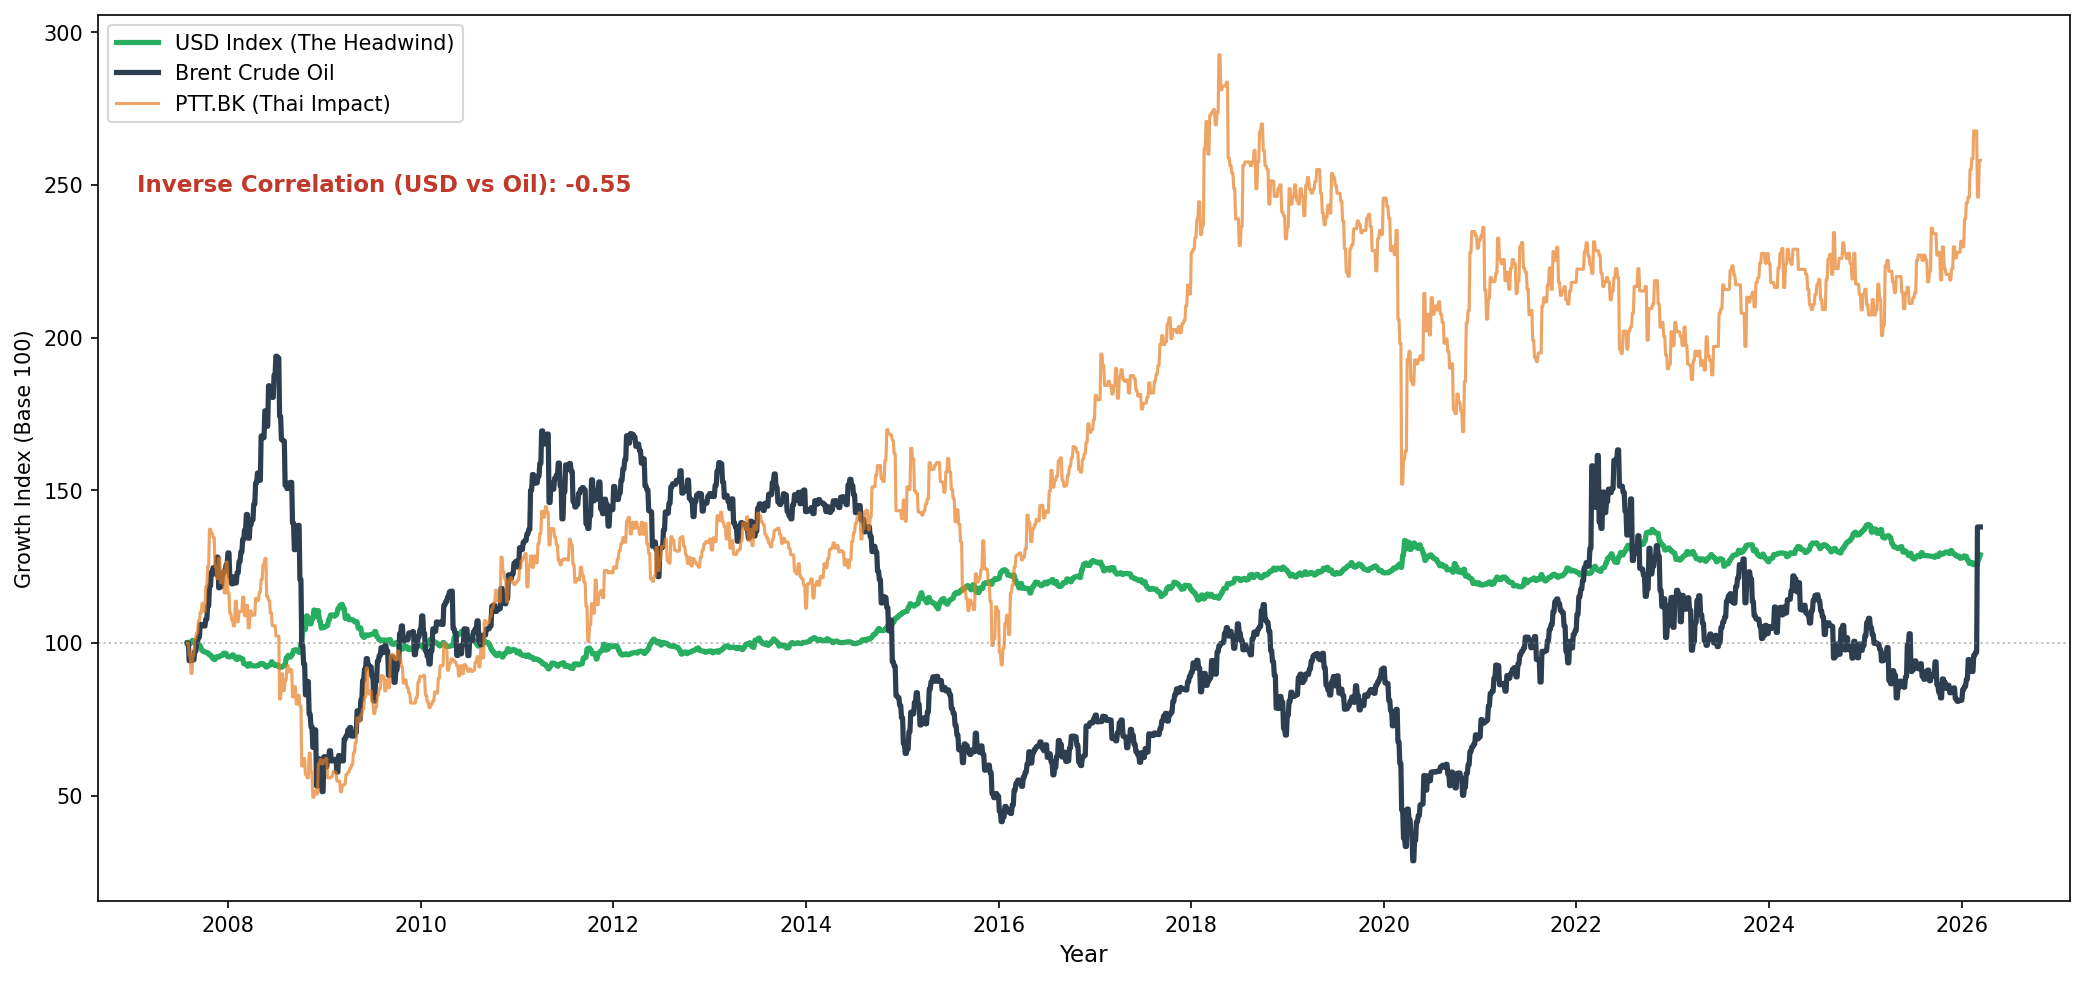

In [27]:
def fig_05_usd_inverse(stocks, fred):
    print("\n[Fig 5] USD vs Energy: The Inverse Relationship")
    def get_clean_series(df, ticker_name, is_fred=False):
        data = df.copy()
        if 'Date' in data.columns:
            data['Date'] = pd.to_datetime(data['Date'])
            data = data.set_index('Date')
        elif not isinstance(data.index, pd.DatetimeIndex):
            data.index = pd.to_datetime(data.index)
        if not is_fred:
            data = data[data['Ticker'] == ticker_name]
        col_to_use = 'DTWEXBGS' if is_fred else 'Close'
        if col_to_use in data.columns:
            target_data = data[[col_to_use]].copy()
            if isinstance(target_data.columns, pd.MultiIndex):
                target_data.columns = target_data.columns.get_level_values(0)
            target_data.columns = [ticker_name]
            return target_data
        return pd.DataFrame()
    try:
        usd_idx = get_clean_series(fred, 'USD_Index', is_fred=True)
        oil_price = get_clean_series(stocks, 'BZ=F')
        ptt_stock = get_clean_series(stocks, 'PTT.BK')
        merged = usd_idx.join(oil_price, how="outer").join(ptt_stock, how="outer")
        merged = merged.sort_index().ffill().dropna()
        if merged.empty: return
        norm = (merged / merged.iloc[0]) * 100
        fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
        ax.plot(norm.index, norm["USD_Index"], color='#27AE60', lw=2.5, label="USD Index (The Headwind)")
        ax.plot(norm.index, norm["BZ=F"], color='#2C3E50', lw=2.5, label="Brent Crude Oil")
        ax.plot(norm.index, norm["PTT.BK"], color='#E67E22', lw=1.5, alpha=0.7, label="PTT.BK (Thai Impact)")
        corr_val = merged['USD_Index'].corr(merged['BZ=F'])
        ax.text(0.02, 0.8, f"Inverse Correlation (USD vs Oil): {corr_val:.2f}",
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                color='#C0392B', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        ax.axhline(100, color='grey', ls=':', lw=1, alpha=0.5)

        ax.set_ylabel("Growth Index (Base 100)")
        ax.set_xlabel("Year", fontsize=11) 
        ax.legend(loc="upper left", frameon=True, facecolor='white')
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "05_usd_vs_energy")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_05_usd_inverse(stocks, fred)


#### การวิเคราะห์ Fig 5: กลไก Inverse Correlation ระหว่าง USD Index กับราคาน้ำมัน

เนื่องจากน้ำมันดิบซื้อขายด้วยสกุลเงินดอลลาร์สหรัฐในตลาดโลก จึงมีความสัมพันธ์เชิงผกผัน (Inverse Relationship) กับค่าเงินดอลลาร์โดยธรรมชาติ กลไกนี้ทำงานผ่าน Purchasing Power Channel — เมื่อดอลลาร์แข็งค่า ประเทศผู้นำเข้าน้ำมัน (จีน, อินเดีย, สหภาพยุโรป) ต้องจ่ายแพงขึ้นในสกุลเงินของตน ส่งผลให้อุปสงค์ลดลงและกดดันราคาน้ำมัน ค่า Correlation ผกผันที่แสดงบนกราฟยืนยันกลไกนี้ด้วยข้อมูลเชิงประจักษ์

สิ่งที่น่าสนใจเพิ่มเติมคือผลกระทบต่อหุ้นพลังงานไทย (PTT.BK) — เมื่อดอลลาร์แข็งค่า PTT ได้รับผลกระทบซ้อนกัน 2 ชั้น (Double Impact) กล่าวคือ ราคาน้ำมันลดลง (กระทบรายได้) และเงินบาทอ่อนค่า (ทำให้ต้นทุนนำเข้าวัตถุดิบสูงขึ้น) ผลกระทบซ้อนนี้อธิบายได้ว่าทำไมหุ้นพลังงานไทยจึงมี Sensitivity ต่อค่าเงินดอลลาร์มากกว่าหุ้นพลังงานสหรัฐฯ และผู้ลงทุนในหุ้นพลังงานไทยจึงต้องติดตาม DXY (Dollar Index) เป็นตัวแปรเสริมในการวิเคราะห์

**Key Findings:**
- USD ↑ → Oil ↓ → Energy Stocks ↓ — กลไกผกผันที่ขับเคลื่อนผ่าน Purchasing Power Channel
- นโยบาย Fed Hawkish (ขึ้นดอกเบี้ย → ดอลลาร์แข็ง) สร้าง Headwind ต่อหุ้นพลังงาน | Fed Dovish สร้าง Tailwind
- หุ้นพลังงานไทยมี Double Currency Exposure ที่ต้องคำนึงเพิ่มเติม


### Fig 6. Industrial Production vs Oil — ภาคเศรษฐกิจจริงกับราคาพลังงาน



[Fig 6] Real Economy: Industrial Production vs Oil Price
  Saved: outputs/figures\06_industrial_vs_oil.png


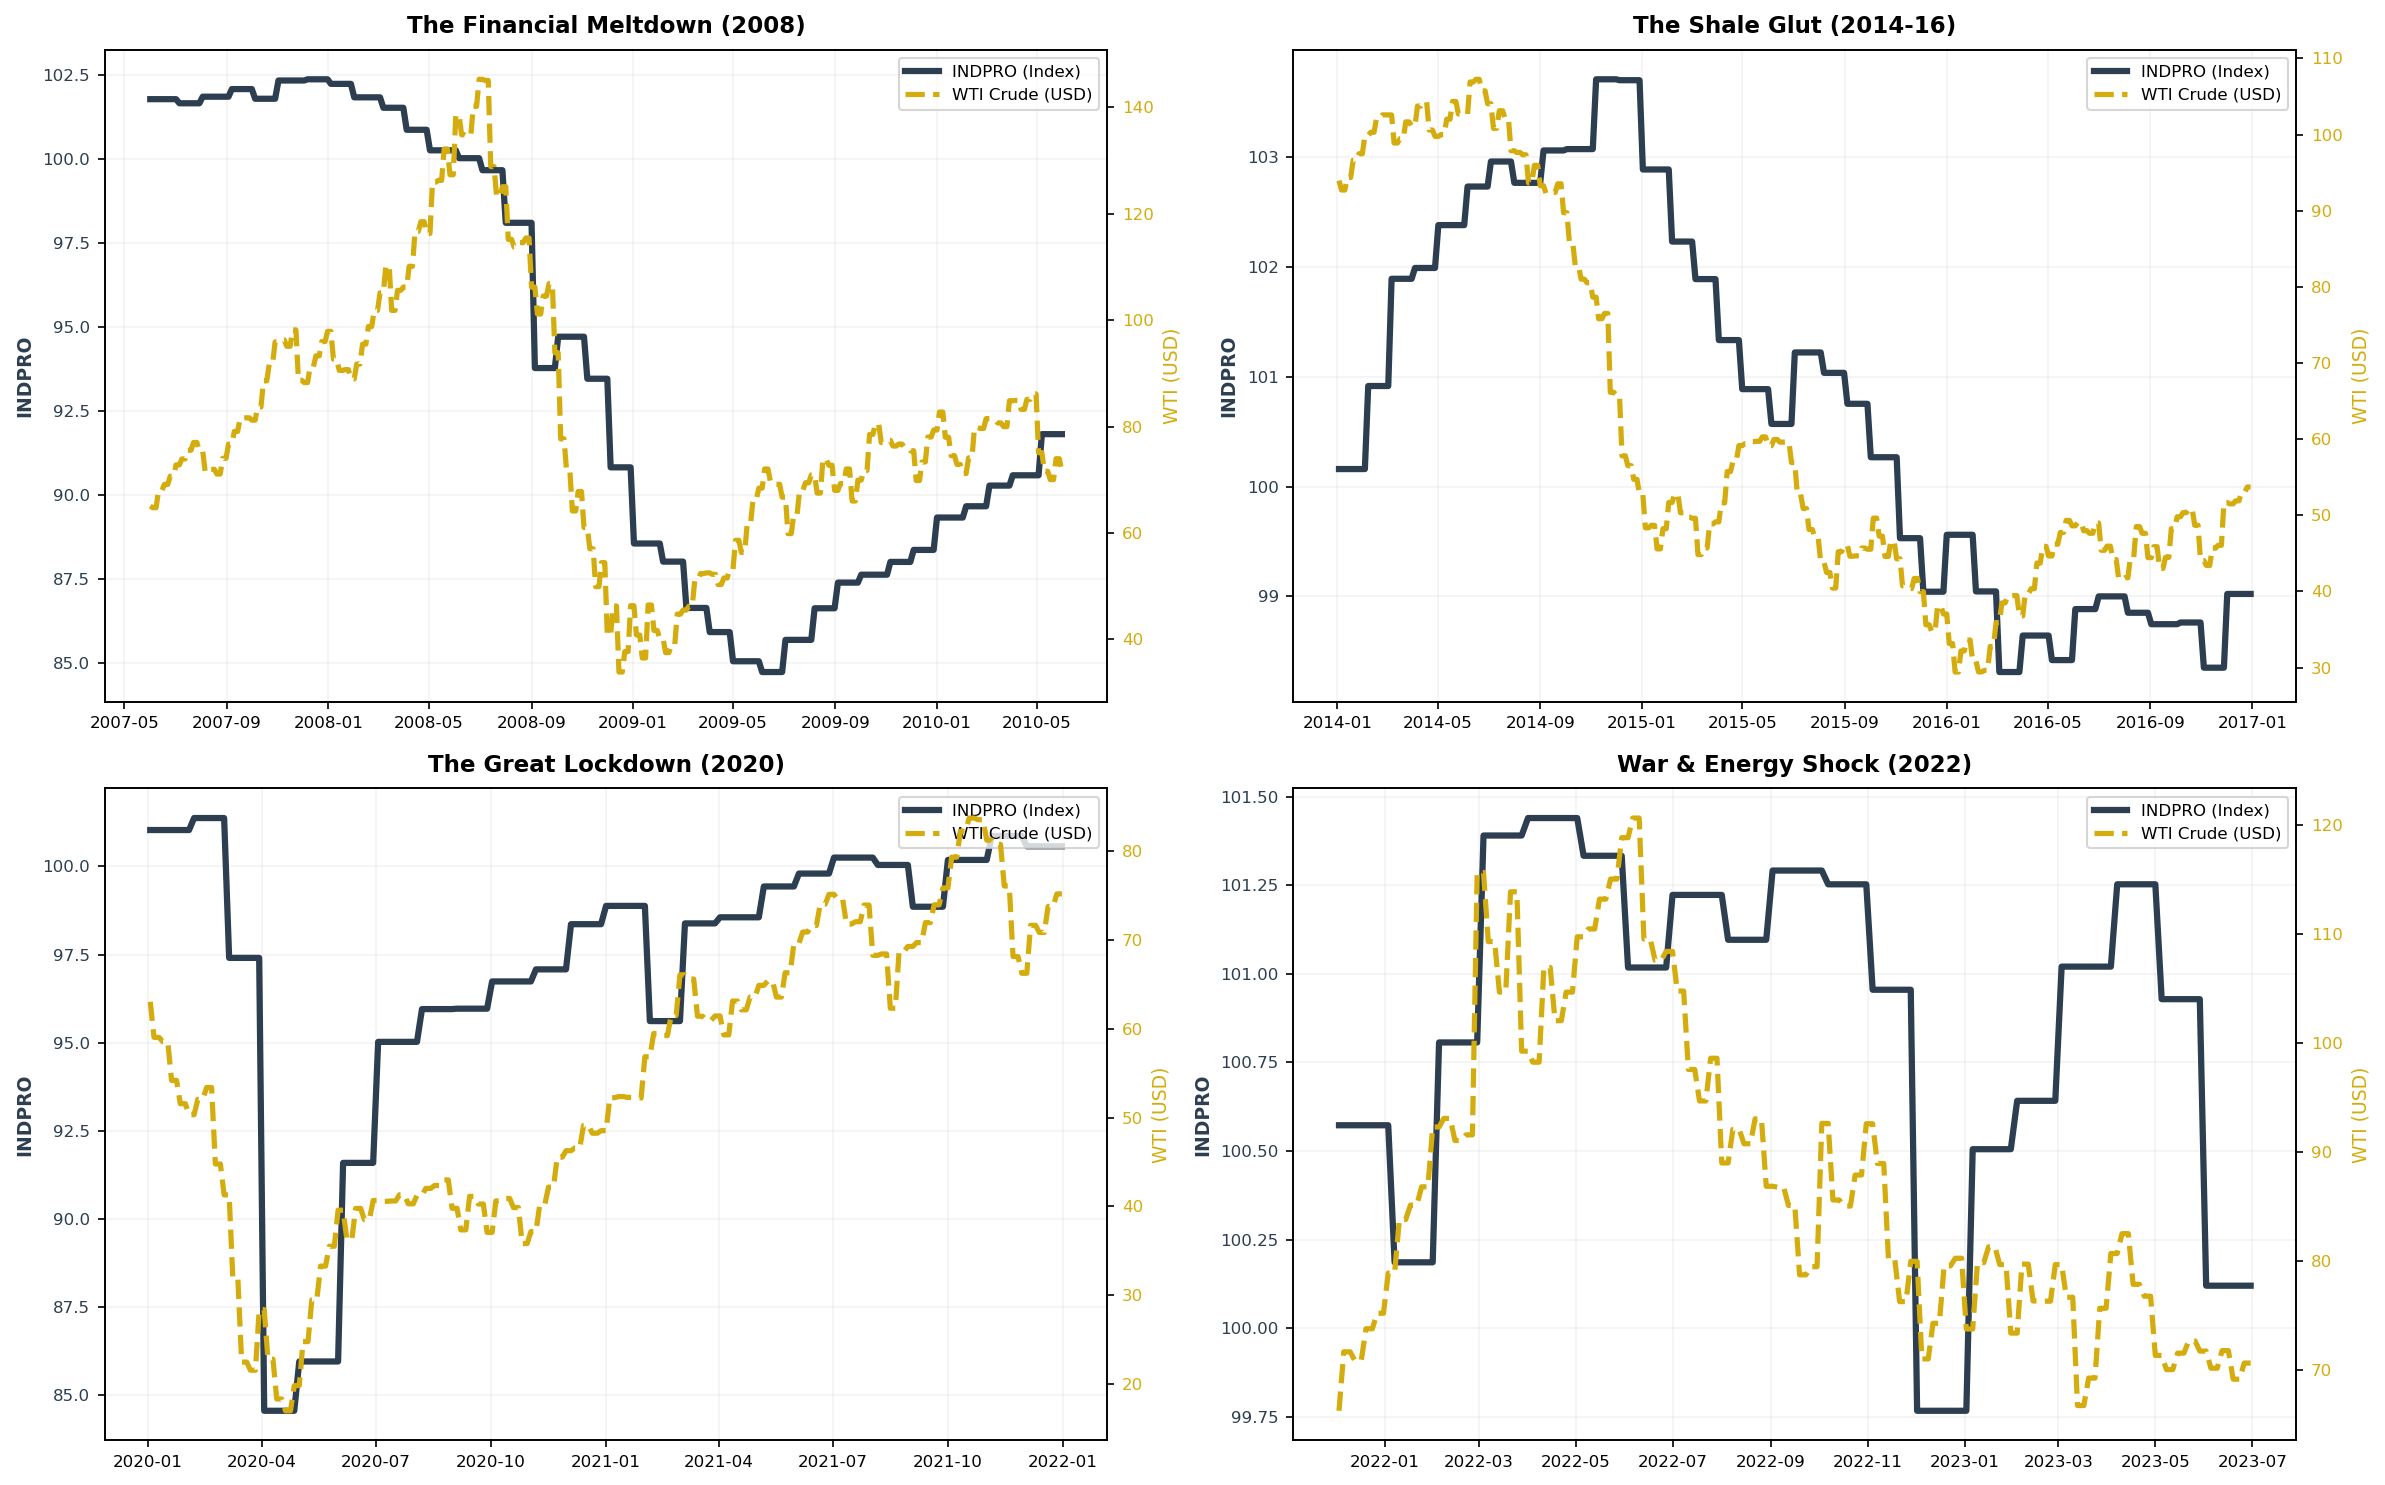

In [28]:
def fig_06_industrial_vs_oil(stocks_df, fred_df):
    print("\n[Fig 6] Real Economy: Industrial Production vs Oil Price")
    try:
        oil = stocks_df[stocks_df['Ticker'] == 'CL=F'].copy()
        if 'Date' not in oil.columns: oil = oil.reset_index()
        oil = oil[['Date', 'Close']].rename(columns={'Close': 'WTI'})

        fred_c = fred_df.copy()
        if 'Date' not in fred_c.columns: fred_c = fred_c.reset_index()
        indpro = fred_c[['Date', 'INDPRO']].copy()

        oil['Date'] = pd.to_datetime(oil['Date'])
        indpro['Date'] = pd.to_datetime(indpro['Date'])
        oil = oil.set_index('Date')
        indpro = indpro.set_index('Date')
        merged = indpro.join(oil, how='outer').sort_index().ffill().dropna()

        crises = [
            ("2007-06-01", "2010-06-01", "The Financial Meltdown (2008)"),
            ("2014-01-01", "2016-12-31", "The Shale Glut (2014-16)"),
            ("2020-01-01", "2021-12-31", "The Great Lockdown (2020)"),
            ("2021-12-01", "2023-06-30", "War & Energy Shock (2022)")
        ]
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=150)
        axes = axes.flatten()
        for i, (start, end, title) in enumerate(crises):
            ax1 = axes[i]
            sub = merged.loc[start:end].copy()
            if sub.empty: continue
            ax1.plot(sub.index, sub['INDPRO'], color='#2C3E50', lw=3, label='INDPRO (Index)')
            ax1.set_ylabel('INDPRO', color='#2C3E50', fontsize=9, fontweight='bold')
            ax1.tick_params(axis='y', labelcolor='#2C3E50', labelsize=8)
            ax2 = ax1.twinx()
            ax2.plot(sub.index, sub['WTI'], color='#D4AC0D', lw=2.5, ls='--', label='WTI Crude (USD)')
            ax2.set_ylabel('WTI (USD)', color='#D4AC0D', fontsize=9)
            ax2.tick_params(axis='y', labelcolor='#D4AC0D', labelsize=8)
            ax1.set_title(title, fontsize=11, fontweight='bold', pad=8)
            ax1.grid(True, alpha=0.15)
            ax1.tick_params(axis='x', labelsize=8)
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1+lines2, labels1+labels2, loc='upper right', fontsize=8, frameon=True)

        plt.tight_layout()
        save_fig(fig, "06_industrial_vs_oil")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_06_industrial_vs_oil(stocks, fred)


#### การวิเคราะห์ Fig 6: ความสัมพันธ์ระหว่าง Industrial Production กับราคาน้ำมันในช่วงวิกฤต

กราฟ Panel 2x2 นี้เปรียบเทียบ INDPRO (Industrial Production Index) กับ WTI Crude ใน 4 ช่วงวิกฤต เพื่อจำแนกประเภทของ Shock ที่ส่งผลต่อตลาดพลังงาน ข้อค้นพบหลักคือวิกฤตแต่ละครั้งมีลักษณะที่ต่างกัน — Great Recession (2008) และ COVID-19 (2020) เป็น Demand Shock ที่ INDPRO ร่วงลงพร้อมกับราคาน้ำมัน ขณะที่สงครามรัสเซีย-ยูเครน (2022) เป็น Supply Shock ที่ INDPRO ยังเติบโตแต่ราคาน้ำมันพุ่งสูง

COVID-19 เป็นกรณีศึกษาที่หายากในทางวิชาการ เพราะเป็น Simultaneous Supply-Demand Shock — ทั้งภาคการผลิตหยุดชะงัก (โรงงานปิด, สายการบินหยุดบิน) และ OPEC ลดการผลิตไม่ทันกับการลดลงของอุปสงค์ ทำให้ WTI ติดลบเป็นครั้งแรกในประวัติศาสตร์ ในทางตรงข้าม Supply Shock จากสงครามมักทำให้ราคาน้ำมันสูงขึ้นขณะที่ภาคการผลิตยังดำเนินต่อ ซึ่งเป็นสภาพแวดล้อมที่เอื้อต่อหุ้น Upstream โดยเฉพาะ

**Key Findings:**
- INDPRO เป็น Leading Indicator ที่มีคุณค่าสำหรับการจำแนกประเภทวิกฤต (Demand Shock vs Supply Shock)
- Supply Shock (สงคราม) → โอกาสสำหรับ Upstream | Demand Shock (COVID) → ความเสี่ยงสูงสำหรับทุกกลุ่ม
- สัญญาณ INDPRO ฟื้นตัวมักนำหน้าการฟื้นตัวของราคาน้ำมัน → ใช้เป็น Entry Signal ได้


---
# Part 3: Crisis Analysis & Volatility Regime
### การวิเคราะห์วิกฤตและรูปแบบความผันผวนตลอด 26 ปี

ตลอดช่วงเวลาที่ศึกษา (2000–2026) ตลาดพลังงานผ่านวิกฤตสำคัญ 6 ครั้ง ได้แก่ Dot-com/Oil Spike, Great Financial Crisis, Shale Revolution, COVID-19 Pandemic, สงครามรัสเซีย-ยูเครน และวิกฤตอิหร่าน ส่วนนี้จะวิเคราะห์ผลกระทบของแต่ละวิกฤตผ่าน 3 มิติ คือ Long-term Price Evolution, ความสัมพันธ์ระหว่าง VIX กับ Energy Volatility และการกระจายตัวทางสถิติของความผันผวนในแต่ละยุค


### Fig 7. Long-term Price Evolution — พัฒนาการราคาหุ้นพลังงาน 26 ปี



[Fig 7] 26-Year Indexed Price Evolution
  Saved: outputs/figures\07_26yr_price_evolution.png


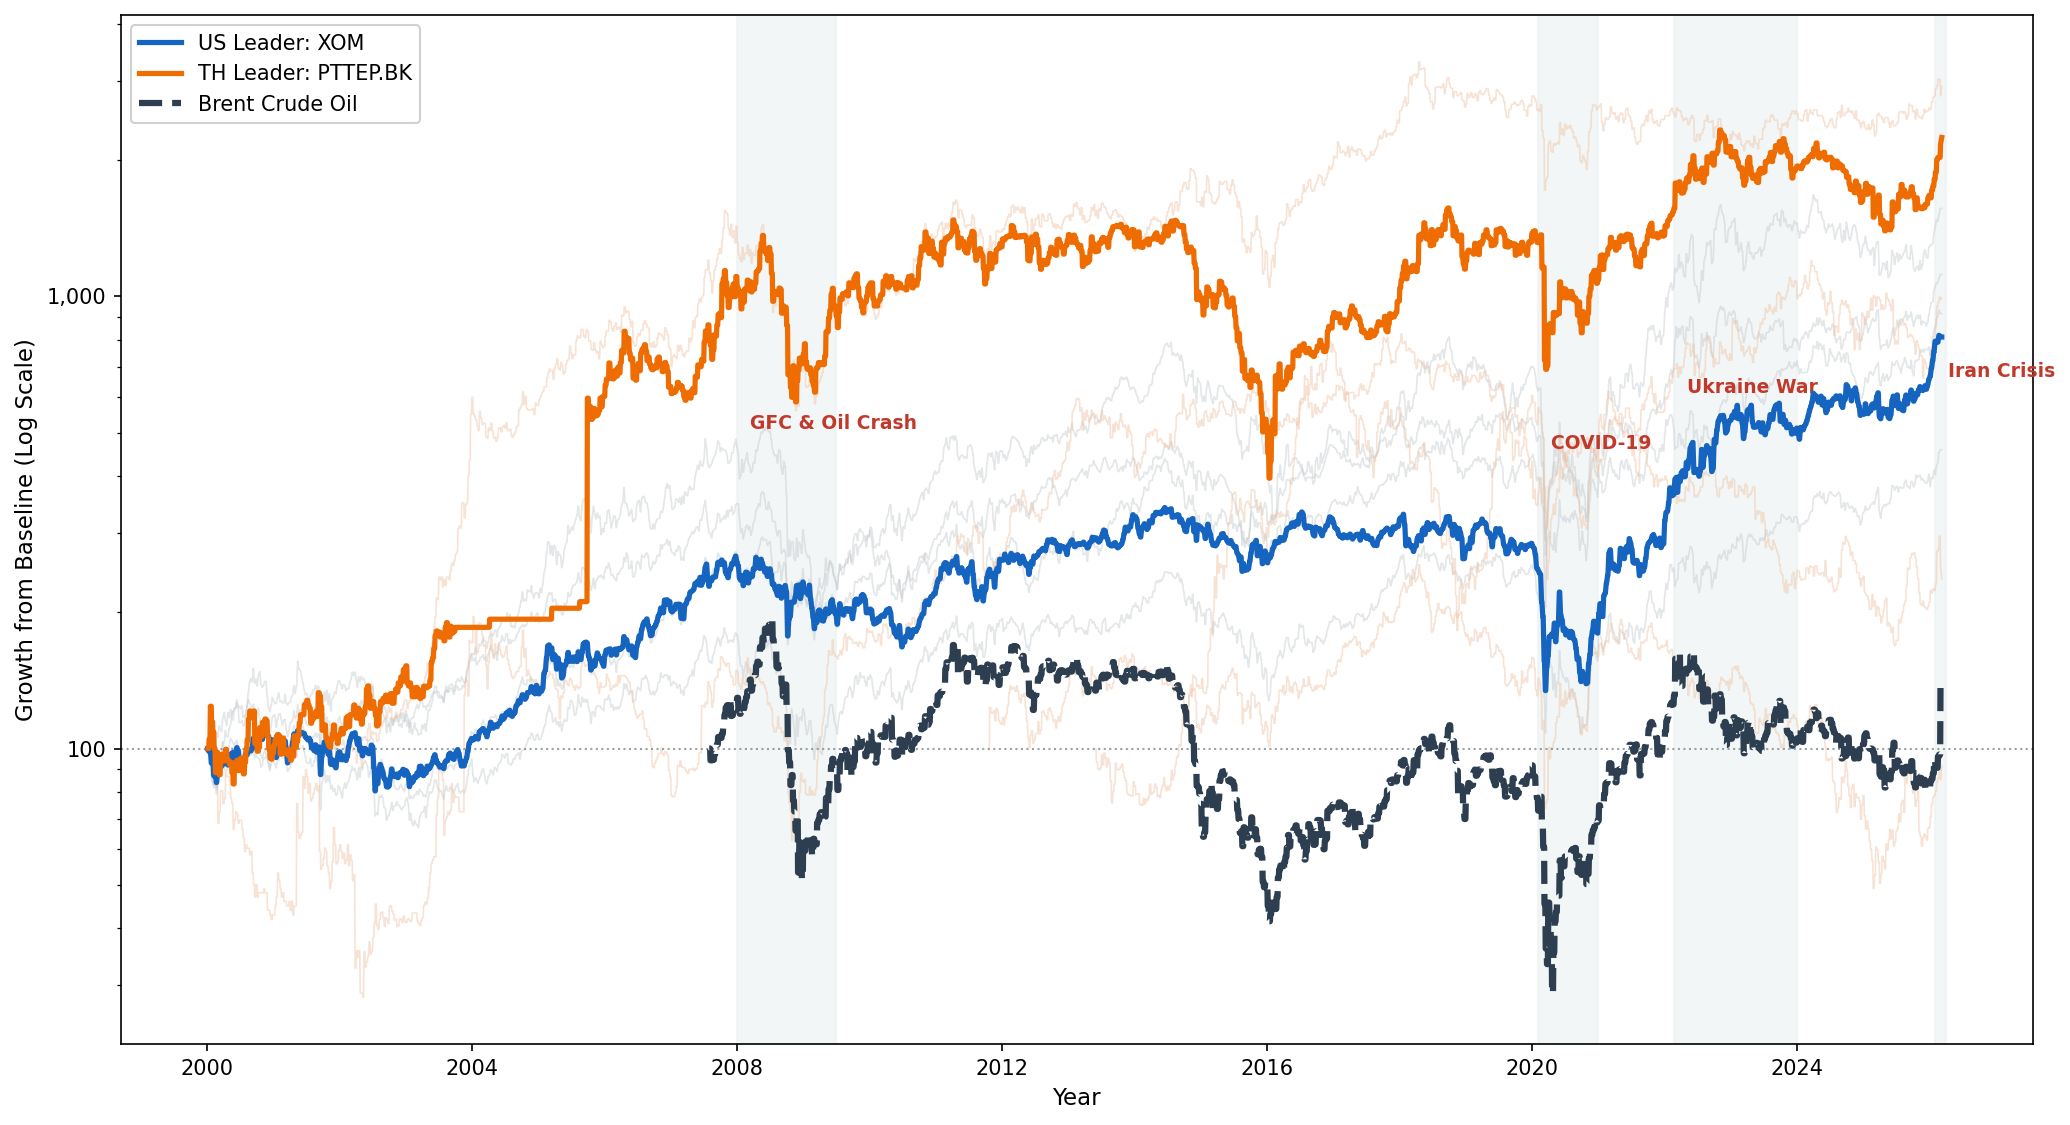

In [29]:
def fig_07_price_evolution(stocks, fred):
    print("\n[Fig 7] 26-Year Indexed Price Evolution")
    idx = pivot_indexed(stocks, ALL_STOCKS + ["BZ=F"])
    highlight_us, highlight_th = "XOM", "PTTEP.BK"
    fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
    for t in US_TICKERS:
        if t != highlight_us: ax.plot(idx.index, idx[t], color='#BDC3C7', alpha=0.4, lw=0.8, zorder=2)
    for t in TH_TICKERS:
        if t != highlight_th: ax.plot(idx.index, idx[t], color='#EDBB99', alpha=0.4, lw=0.8, zorder=2)
    ax.plot(idx.index, idx[highlight_us], color=C_BLUE, lw=2.5, label=f"US Leader: {highlight_us}", zorder=5)
    ax.plot(idx.index, idx[highlight_th], color=C_ORANGE, lw=2.5, label=f"TH Leader: {highlight_th}", zorder=5)
    ax.plot(idx.index, idx["BZ=F"], color='#2C3E50', lw=3, ls='--', label="Brent Crude Oil", zorder=6)
    ax.axhline(100, color='#7F8C8D', lw=1, ls=':', alpha=0.8)
    crises = [("2008-01-01","2009-06-30","GFC & Oil Crash",500),("2020-02-01","2020-12-31","COVID-19",450),
              ("2022-02-24","2023-12-31","Ukraine War",600),("2026-02-01","2026-03-31","Iran Crisis",650)]
    for s, e, lbl, y in crises:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color='#ECF0F1', alpha=0.6, zorder=1)
        ax.text(pd.Timestamp(s), y, f"  {lbl}", fontsize=9, fontweight='bold', color='#C0392B', va='bottom')
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Growth from Baseline (Log Scale)", fontsize=11)
    ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    save_fig(fig, "07_26yr_price_evolution")
    plt.show()

fig_07_price_evolution(stocks, fred)

#### การวิเคราะห์ Fig 7: Indexed Price Evolution ในระยะยาว (Log Scale)

กราฟนี้แสดง Indexed Price (ฐาน 100 = ม.ค. 2000) ของหุ้นพลังงาน 10 ตัว บน Log Scale เพื่อให้สามารถเปรียบเทียบอัตราการเติบโตสะสม (Cumulative Growth Rate) ได้อย่างเที่ยงตรง โดยไม่ถูกบิดเบือนจากค่าสัมบูรณ์ที่ต่างกัน เส้น Highlight 2 เส้น — XOM (ตัวแทน US) และ PTTEP (ตัวแทน Thai) — แสดงให้เห็นว่าหุ้นทั้งสองตัวสามารถฟื้นกลับมาทำจุดสูงสุดใหม่ได้หลังทุกวิกฤต ขณะที่หุ้นบางตัว (เส้นสีจาง) ไม่สามารถกลับมาถึงระดับเดิม

แถบสีเทาบนกราฟแสดงช่วงวิกฤตสำคัญ 4 ครั้ง สิ่งที่สังเกตได้คือหุ้นทุกตัว "ร่วงพร้อมกัน" ในช่วงวิกฤต (Correlation Spike) แต่ "ฟื้นตัวไม่เท่ากัน" (Asymmetric Recovery) ซึ่งเป็นหลักฐานว่าคุณภาพของบริษัท (Competitive Advantage, Balance Sheet Strength, Capital Discipline) เป็นตัวกำหนดความสามารถในการฟื้นตัวระยะยาว ไม่ใช่แค่ทิศทางของราคาน้ำมัน

**Key Findings:**
- Log Scale เผยให้เห็นว่าหุ้นที่ดู "เติบโตใกล้เคียงกัน" บน Linear Scale อาจมีผลตอบแทนสะสมต่างกัน 3-5 เท่า
- XOM แสดง Recovery Power ที่สม่ำเสมอ สอดคล้องกับโครงสร้างธุรกิจที่กระจายตัว (Integrated Oil Major)
- การคัดเลือกหุ้น (Stock Selection) มีความสำคัญไม่น้อยกว่าการเลือกจังหวะ (Market Timing)


### Fig 8. VIX vs Energy Volatility — ดัชนีความกลัวในฐานะ Leading Indicator



[Fig 8] VIX vs Energy Sector Volatility
  Saved: outputs/figures\08_vix_vs_energy_vol.png


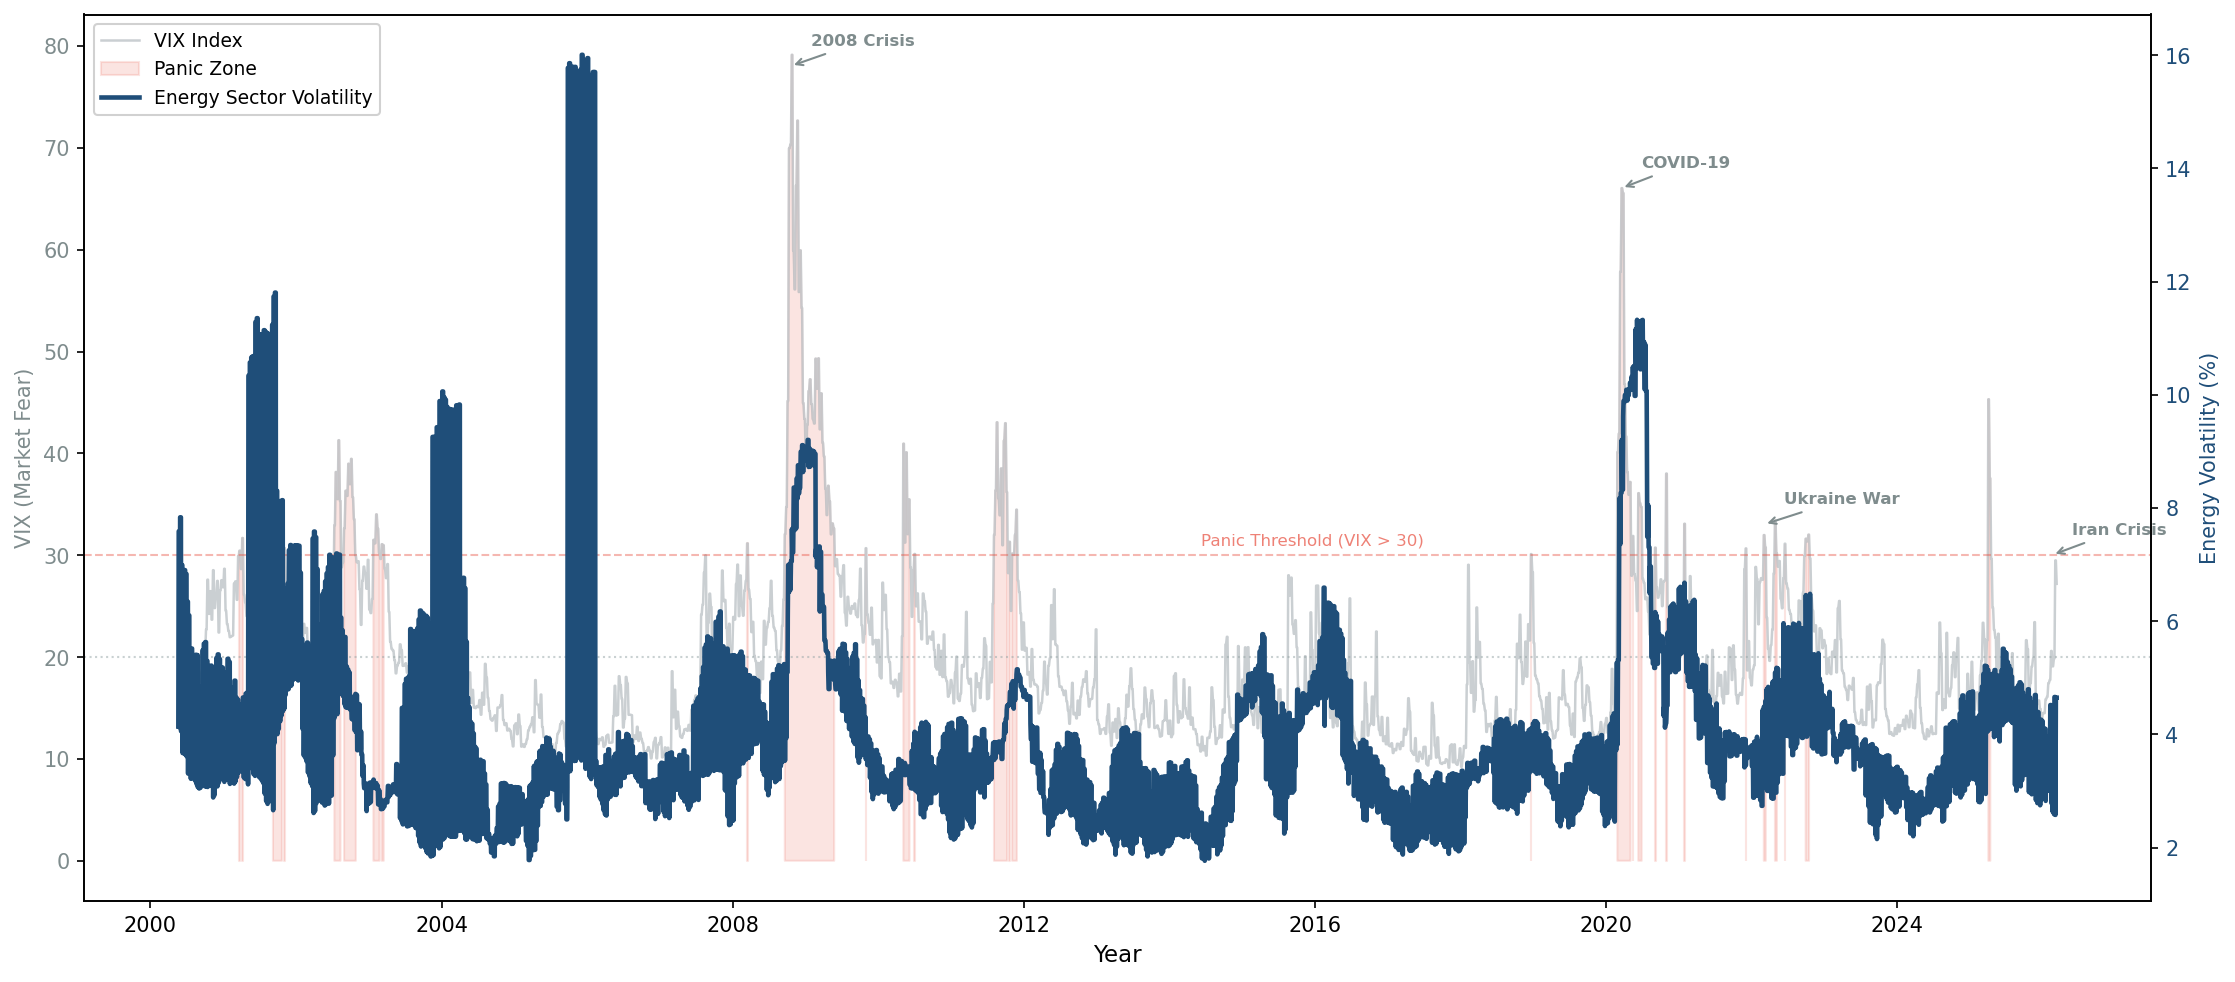

In [30]:
def fig_08_vix_volatility(stocks, fred):
    print("\n[Fig 8] VIX vs Energy Sector Volatility")
    try:
        vix_df = fred.copy()
        vix_df['Date'] = pd.to_datetime(vix_df.get('Date', vix_df.index))
        vix = vix_df.set_index('Date')[["VIXCLS"]].dropna()
        stk_data = stocks.copy()
        if 'Date' in stk_data.columns: stk_data['Date'] = pd.to_datetime(stk_data['Date'])
        else: stk_data = stk_data.reset_index(); stk_data['Date'] = pd.to_datetime(stk_data['Date'])
        vol_avg = stk_data[stk_data["Ticker"].isin(ALL_STOCKS)].groupby('Date')["Rolling_Vol_20w"].mean()
        vol_df = pd.DataFrame(vol_avg).rename(columns={"Rolling_Vol_20w": "Avg_Energy_Vol"})
        vol_df.index = pd.to_datetime(vol_df.index)
        merged = vix.join(vol_df, how="outer").sort_index().ffill().dropna()
        fig, ax1 = plt.subplots(figsize=(15, 7), dpi=150)
        ax1.plot(merged.index, merged["VIXCLS"], color='#BDC3C7', lw=1.2, alpha=0.8, label="VIX Index")
        ax1.set_ylabel("VIX (Market Fear)", color='#7F8C8D')
        ax1.tick_params(axis='y', labelcolor='#7F8C8D')
        ax1.axhline(20, color='#95A5A6', ls=':', lw=1, alpha=0.5)
        ax1.axhline(30, color='#E74C3C', ls='--', lw=1, alpha=0.4)
        ax1.text(merged.index[2200], 31, "Panic Threshold (VIX > 30)", color='#E74C3C', fontsize=8, alpha=0.7)
        ax2 = ax1.twinx()
        ax2.plot(merged.index, merged["Avg_Energy_Vol"]*100, color='#1F4E79', lw=2.2, label="Energy Sector Volatility")
        ax2.set_ylabel("Energy Volatility (%)", color='#1F4E79')
        ax2.tick_params(axis='y', labelcolor='#1F4E79')
        ax1.fill_between(merged.index, 0, merged["VIXCLS"], where=(merged["VIXCLS"]>=30), color='#E74C3C', alpha=0.15, label="Panic Zone")
        h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1+h2, l1+l2, loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)
        ax1.set_xlabel("Year", fontsize=11)
        for date, y, lbl in [("2008-10-15",78,"2008 Crisis"),("2020-03-15",66,"COVID-19"),("2022-03-01",33,"Ukraine War"),("2026-02-15",30,"Iran Crisis")]:
            ax1.annotate(lbl, xy=(pd.Timestamp(date),y), xytext=(10,10), textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color='#7F8C8D'), fontsize=8, color='#7F8C8D', fontweight='bold')

        plt.tight_layout(rect=[0, 0.05, 1, 1])
        save_fig(fig, "08_vix_vs_energy_vol")
        plt.show()
    except Exception as e:
        print(f"❌ Error: {e}")

fig_08_vix_volatility(stocks, fred)


#### การวิเคราะห์ Fig 8: ความสัมพันธ์ระหว่าง VIX กับ Energy Sector Volatility

VIX Index (CBOE Volatility Index) วัดความคาดหวังของตลาดเกี่ยวกับ Implied Volatility ของ S&P 500 ใน 30 วันข้างหน้า กราฟ Dual-Axis นี้แสดง VIX เทียบกับ 20-Week Rolling Volatility เฉลี่ยของหุ้นพลังงาน 10 ตัว พร้อม Panic Zone (VIX > 30) ที่แรเงาสีแดง ค่า Correlation ระหว่างทั้งสองตัวแปรอยู่ที่ระดับสูง (> 0.8) แสดงว่า Systematic Market Risk เป็นตัวขับเคลื่อนหลักของ Energy Sector Volatility

ข้อสังเกตที่มีคุณค่าเชิงปฏิบัติคือ VIX มักพุ่งขึ้นก่อน (Lead) Energy Volatility ประมาณ 1-2 สัปดาห์ — สอดคล้องกับทฤษฎี Information Cascade ที่ตลาดออปชัน (ที่ VIX วัด) สะท้อนข้อมูลเร็วกว่าตลาดหุ้นรายตัว คุณสมบัตินี้ทำให้ VIX สามารถใช้เป็น Early Warning System สำหรับการบริหารความเสี่ยงพอร์ตพลังงานได้

**Key Findings:**
- VIX > 30 เป็นสัญญาณเตือนว่าหุ้นพลังงานกำลังจะเข้าสู่ช่วง High Volatility → ควรพิจารณา Hedge หรือลดขนาด Position
- VIX ที่พุ่งสูงแล้วเริ่มลดลง มักตรงกับ Contrarian Entry Point — จุดที่ให้ Risk-Reward Ratio ดีที่สุด
- ช่วงที่ VIX อยู่ต่ำกว่า 20 เป็นเวลานาน (Low Volatility Regime) มักเป็นช่วงก่อนเกิด Volatility Spike ครั้งถัดไป


### Fig 9. Volatility Regime Analysis — การกระจายตัวของความเสี่ยงในแต่ละยุค



[Fig 9] Volatility Distribution Across Crises
  Saved: outputs/figures\09_volatility_anatomy.png


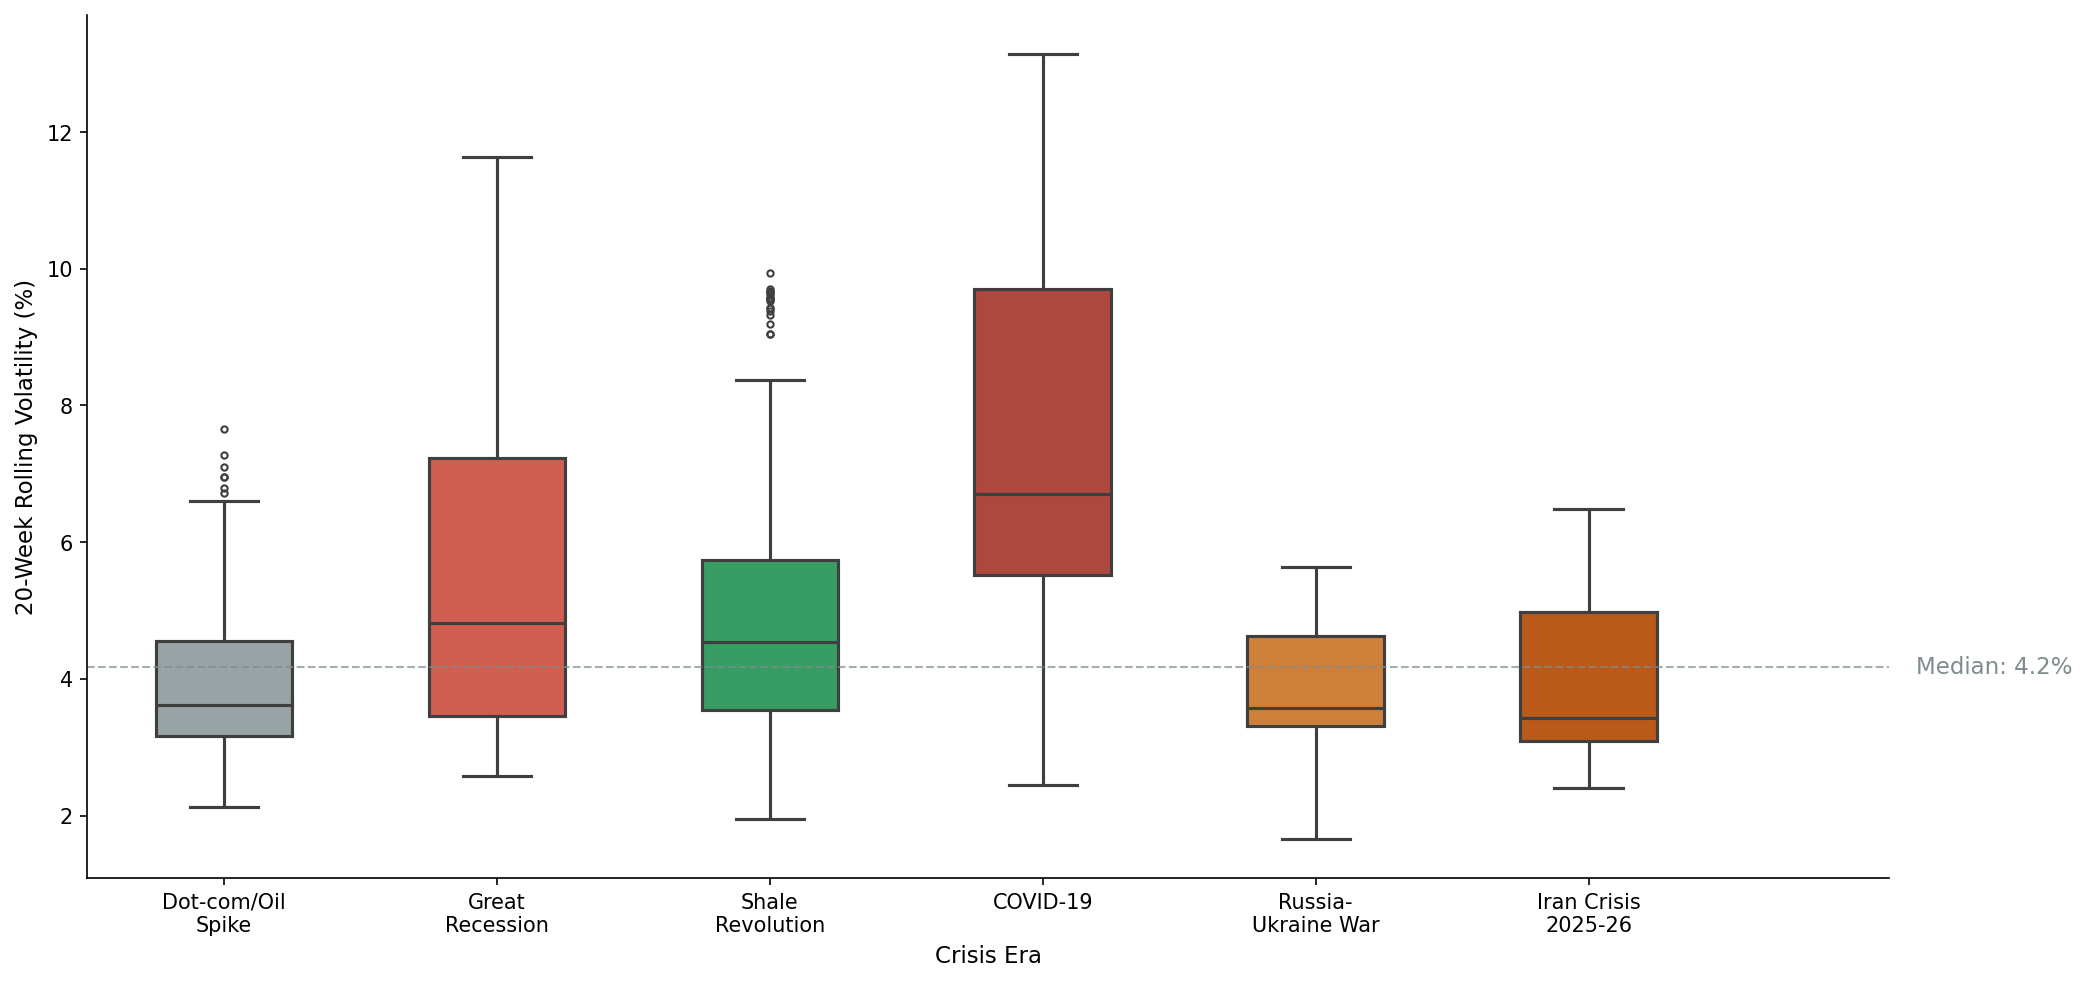

In [31]:
def fig_09_volatility_anatomy(stocks):

    print("\n[Fig 9] Volatility Distribution Across Crises")

    import matplotlib.pyplot as plt
    import seaborn as sns
    import textwrap

    df = stocks.copy()

    if df.index.name != 'Date':
        df = df.set_index('Date')

    df = df[~df.index.duplicated(keep='last')]

    key_eras = [
        "Dot-com/Oil Spike",
        "Great Recession",
        "Shale Revolution",
        "COVID-19",
        "Russia-Ukraine War",
        "Iran Crisis 2025-26"
    ]

    sub = df[df["crisis_era"].isin(key_eras)].copy()
    sub["Vol_Pct"] = sub["Rolling_Vol_20w"] * 100

    fig, ax = plt.subplots(figsize=(14, 7), dpi=150)

    palette = {
        "COVID-19":"#C0392B",
        "Great Recession":"#E74C3C",
        "Russia-Ukraine War":"#E67E22",
        "Iran Crisis 2025-26":"#D35400",
        "Dot-com/Oil Spike":"#95A5A6",
        "Shale Revolution":"#27AE60"
    }

    # ✅ plot ครั้งเดียวพอ
    sns.boxplot(
        data=sub,
        x="crisis_era",
        y="Vol_Pct",
        order=key_eras,
        palette=palette,
        fliersize=3,
        ax=ax,
        width=0.5,
        linewidth=1.5,
        whis=1.5
    )

    # ===== label 2 บรรทัด + ตรง =====
    def wrap_2_lines(text, width=12):
        lines = textwrap.wrap(text, width)
        return "\n".join(lines[:2])

    new_labels = [wrap_2_lines(label, 12) for label in key_eras]

    ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=10)

    # ===== median =====
    gm = sub["Vol_Pct"].median()

    ax.axhline(gm, color="#7F8C8D", ls="--", lw=1, alpha=0.7)

    # ✅ เพิ่มพื้นที่ขวา
    ax.set_xlim(-0.5, len(key_eras) - 0.7 + 0.8)

    # ✅ median ออกไปขวานอกกราฟ
    ax.text(
        len(key_eras) + 0.2,
        gm,
        f"Median: {gm:.1f}%",
        color="#7F8C8D",
        fontsize=11,
        va='center',
        ha='left'
    )

    # ===== labels =====
    ax.set_xlabel("Crisis Era", fontsize=11)
    ax.set_ylabel("20-Week Rolling Volatility (%)", fontsize=11)

    # ❌ เอา rotation เดิมออก (สำคัญมาก)
    # plt.xticks(rotation=15, ha="right")  ← ลบออก

    # ===== clean look =====
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])

    save_fig(fig, "09_volatility_anatomy")
    plt.show()


fig_09_volatility_anatomy(stocks)

#### การวิเคราะห์ Fig 9: Statistical Distribution ของ Volatility ข้ามช่วงวิกฤต

Box Plot นี้แสดงการกระจายตัวทางสถิติของ 20-Week Rolling Volatility ใน 6 ยุคสำคัญ เครื่องมือนี้ให้ข้อมูลที่สมบูรณ์กว่ากราฟเส้น — โดย Box Width สะท้อน Interquartile Range (IQR) หรือ "ระยะเวลาที่ความไม่แน่นอนดำรงอยู่" ขณะที่ Outlier Points แสดง "ค่า Extreme" ที่เกิดขึ้นชั่วคราว

ผลการวิเคราะห์แสดงว่า COVID-19 สร้าง Volatility Spike สูงสุด (Outlier สูงที่สุด) แต่เป็นวิกฤตที่ "รุนแรงแต่สั้น" (Sharp but Short) เห็นได้จาก Box ที่ไม่กว้างมาก ในทางตรงข้าม Great Recession มี Box กว้างที่สุด สะท้อนว่าความไม่แน่นอนกินเวลาหลายเดือนถึงหลายปี (Sustained Uncertainty) ส่วน Shale Revolution (สีเขียว) มี Box แคบที่สุดและ Median ต่ำที่สุด แสดงว่าเป็นยุคที่เสถียรที่สุดในรอบ 26 ปี

**Key Findings:**
- การจำแนก Volatility Regime (Sharp vs Sustained) ช่วยกำหนดกลยุทธ์ที่เหมาะสม: Sharp Crisis → Contrarian Buy ได้เร็ว | Sustained Crisis → ต้องรอนานกว่า
- Shale Revolution Period เป็นสภาพแวดล้อมที่เอื้อต่อกลยุทธ์ Buy & Hold มากที่สุด
- Global Median Line ช่วยให้ประเมินได้ว่า Volatility ปัจจุบันอยู่สูงหรือต่ำกว่าค่าปกติ


---
# Part 4: Comparative Performance & Event Studies
### การเปรียบเทียบผลตอบแทนและการศึกษาเหตุการณ์เฉพาะ

ส่วนนี้จะเปรียบเทียบผลการดำเนินงานจริง (Realized Performance) ของหุ้นพลังงานไทยกับสหรัฐฯ ผ่าน 5 มิติ ได้แก่ ผลตอบแทนเฉลี่ยในช่วงวิกฤต, Event Study สงครามรัสเซีย-ยูเครน, Event Study วิกฤตอิหร่าน, Recovery Speed Analysis, และ Maximum Drawdown Comparison


### Fig 10. Cross-Market Resilience — ผลตอบแทนเฉลี่ยในช่วงวิกฤต Thai vs US



[Fig 10] Historical Resilience: Thai vs US
  Saved: outputs/figures\10_resilience.png


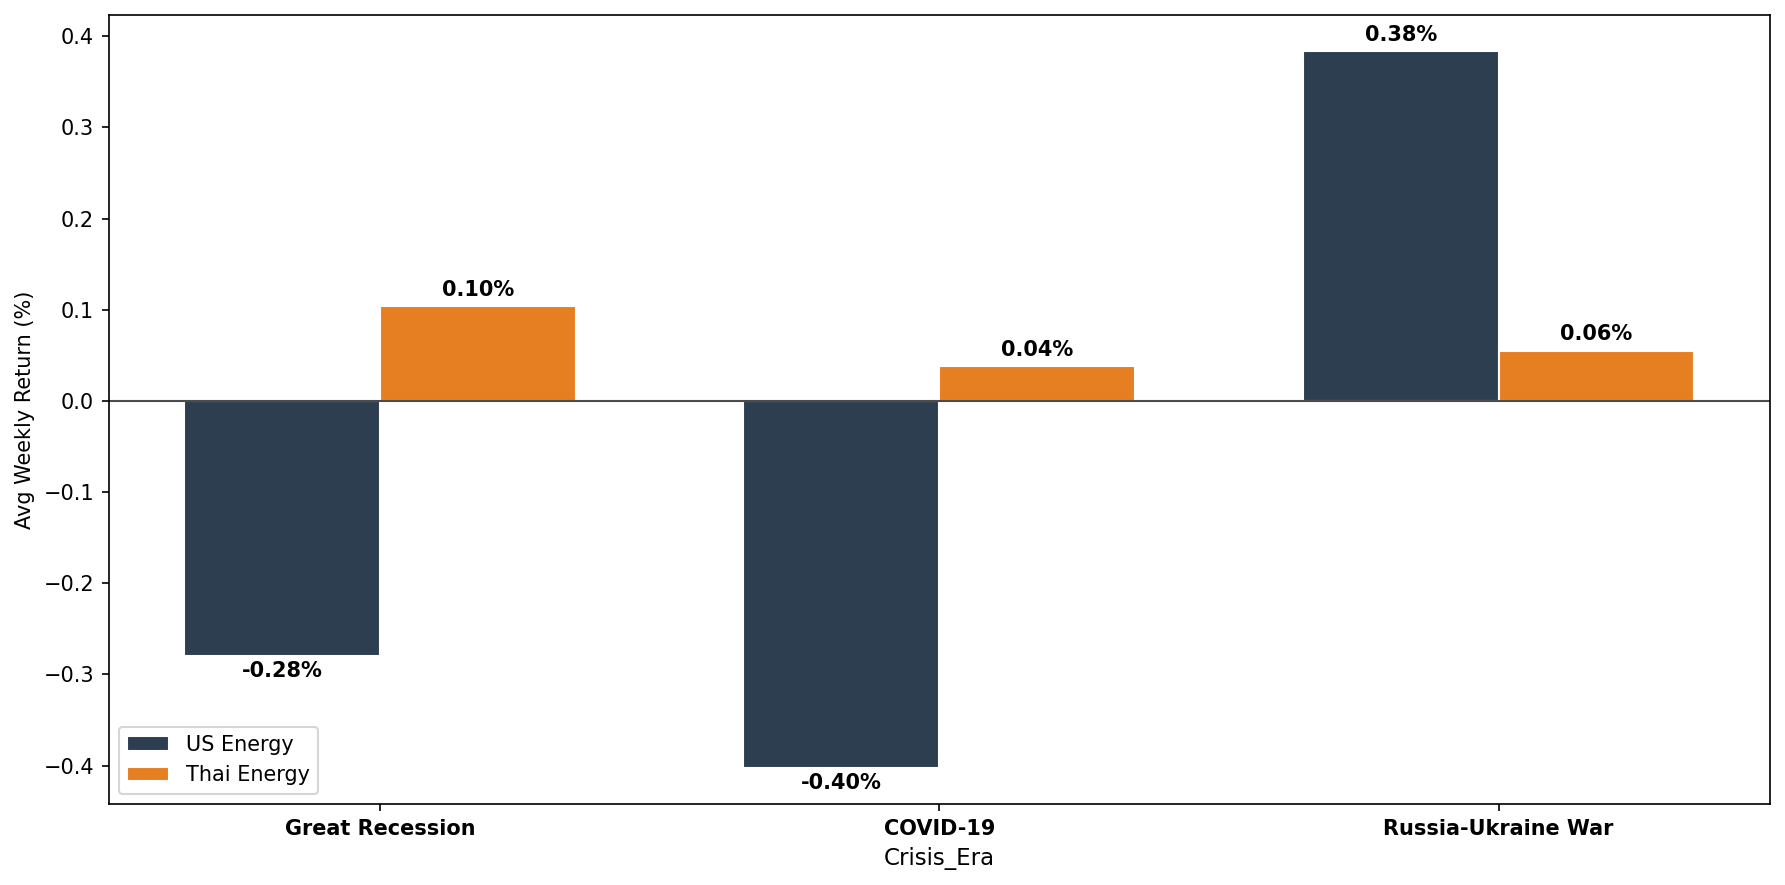

In [32]:
def fig_10_resilience(stocks):
    print("\n[Fig 10] Historical Resilience: Thai vs US")
    historical_eras = ["Great Recession", "COVID-19", "Russia-Ukraine War"]
    us_avg, th_avg = [], []
    for era in historical_eras:
        sub = stocks[stocks["crisis_era"] == era]
        us_ret = sub[sub["Ticker"].isin(US_TICKERS)]["Weekly_Return"].mean() * 100
        th_ret = sub[sub["Ticker"].isin(TH_TICKERS)]["Weekly_Return"].mean() * 100
        us_avg.append(us_ret if not np.isnan(us_ret) else 0)
        th_avg.append(th_ret if not np.isnan(th_ret) else 0)
    x = np.arange(len(historical_eras)); w = 0.35
    fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
    r1 = ax.bar(x-w/2, us_avg, w, color='#2C3E50', label="US Energy", edgecolor='white')
    r2 = ax.bar(x+w/2, th_avg, w, color='#E67E22', label="Thai Energy", edgecolor='white')
    def al(rects):
        for r in rects:
            h=r.get_height()
            ax.annotate(f'{h:.2f}%',xy=(r.get_x()+r.get_width()/2,h),xytext=(0,3 if h>0 else -12),
                       textcoords="offset points",ha='center',va='bottom',fontsize=10,fontweight='bold')
    al(r1); al(r2)
    ax.axhline(0,color='black',lw=1,alpha=0.7); ax.set_xticks(x); ax.set_xticklabels(historical_eras,fontweight='bold')
    ax.set_ylabel("Avg Weekly Return (%)"); ax.legend(loc="lower left",frameon=True,facecolor='white',fontsize=10)
    ax.set_xlabel("Crisis_Era",fontsize=11)
    plt.tight_layout(); save_fig(fig, "10_resilience"); plt.show()

fig_10_resilience(stocks)


#### การวิเคราะห์ Fig 10: Comparative Average Returns ในช่วงวิกฤต

Grouped Bar Chart นี้เปรียบเทียบผลตอบแทนเฉลี่ยรายสัปดาห์ (Average Weekly Return) ของกลุ่มหุ้นพลังงาน US กับ Thai ใน 3 ช่วงวิกฤตสำคัญ ผลลัพธ์ไม่ได้ชี้ว่าฝั่งใดฝั่งหนึ่ง "ชนะ" ทุกวิกฤต แต่แสดง Pattern ที่สม่ำเสมอ — US Energy มักให้ Upside ที่สูงกว่าในช่วง Recovery ขณะที่ Thai Energy บางครั้งมี Downside Protection ที่ดีกว่าในช่วงขาลง

ปัจจัยเชิงโครงสร้างที่อธิบายความแตกต่างนี้ ได้แก่ ความลึกของตลาดทุน (Market Depth) ที่สหรัฐฯ สูงกว่าอย่างมีนัยสำคัญ ส่งผลให้มี Contrarian Capital ไหลเข้าเร็วกว่าในจังหวะวิกฤต นอกจากนี้ หุ้นพลังงาน US มี Global Investor Base ที่กว้างกว่า ขณะที่หุ้นไทยพึ่งพาการลงทุนจากต่างชาติซึ่งมักไหลออกในช่วง Risk-Off (Capital Flight)

**Key Findings:**
- US Energy แสดง Recovery Alpha ที่สูงกว่า Thai ในทุกวิกฤตที่ศึกษา → เหมาะเป็น Core Growth Component
- Thai Energy อาจให้ Downside Buffer ในบางวิกฤต → เหมาะเป็น Stabilizing Component
- กลยุทธ์ที่มีประสิทธิภาพคือ Blended Allocation (US Core + Thai Satellite) เพื่อใช้ประโยชน์จากทั้งสองลักษณะ


### Fig 11. Event Study: สงครามรัสเซีย-ยูเครน — High-Beta vs Low-Beta



[Fig 11] Beta Battle: Russia-Ukraine War
  Saved: outputs/figures\11_beta_ukraine.png


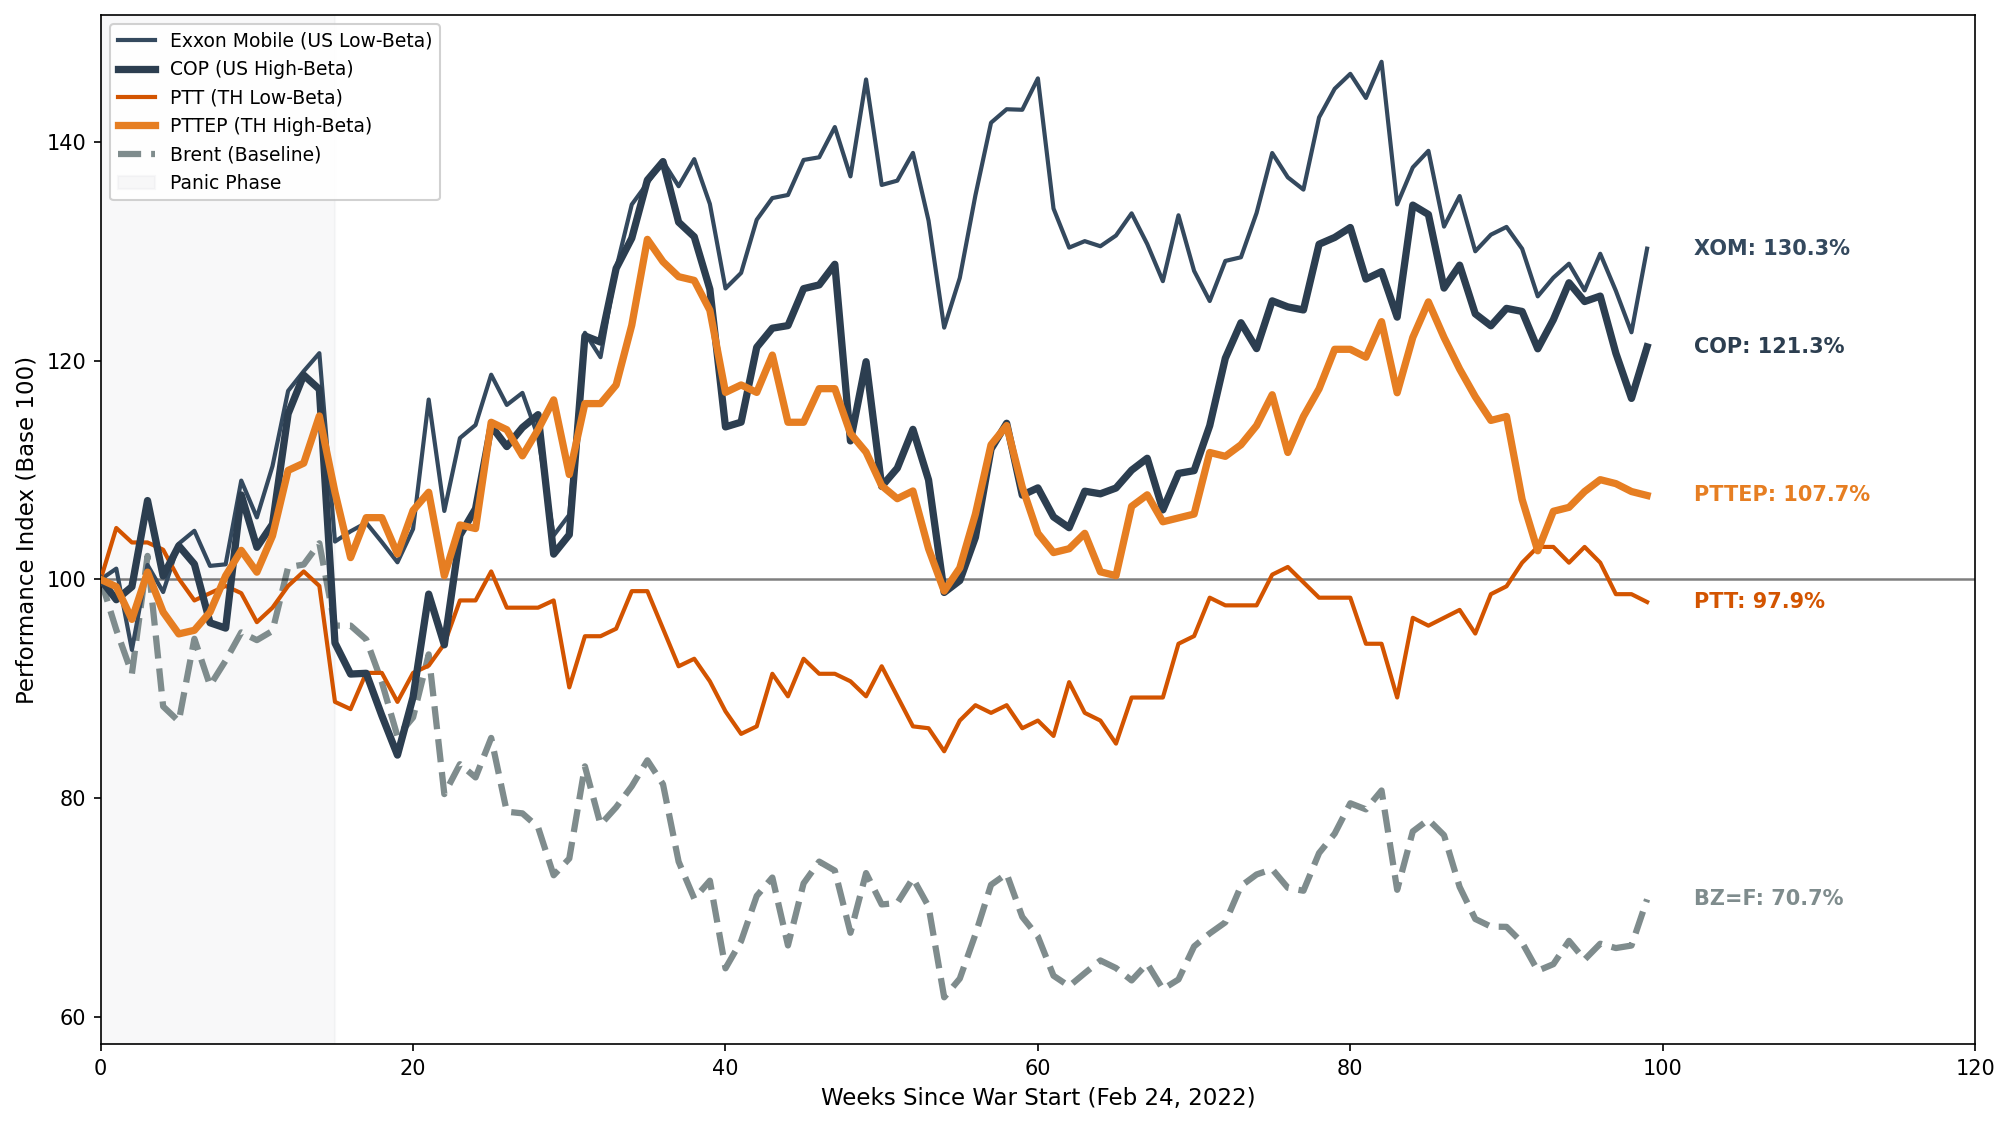

In [33]:
def fig_11_beta_ukraine(stocks):
    print("\n[Fig 11] Beta Battle: Russia-Ukraine War")

    war_start = pd.Timestamp("2022-02-24")
    sub = stocks[stocks.index >= war_start].copy()

    tickers = ["XOM","COP","PTT.BK","PTTEP.BK","BZ=F"]

    sm = {
        "BZ=F":('#7F8C8D',3.0,'--',"Brent (Baseline)",2),
        "COP":('#2C3E50',3.5,'-',"COP (US High-Beta)",5),
        "XOM":('#34495E',2.0,'-',"Exxon Mobile (US Low-Beta)",4),
        "PTTEP.BK":('#E67E22',3.5,'-',"PTTEP (TH High-Beta)",5),
        "PTT.BK":('#D35400',2.0,'-',"PTT (TH Low-Beta)",4)
    }

    fig, ax = plt.subplots(figsize=(15, 8), dpi=150)

    # หา max length
    max_len = max(
        len(sub[sub["Ticker"] == t]["Close"].iloc[:100])
        for t in tickers
    )

    for t in tickers:
        ts = sub[sub["Ticker"] == t]["Close"].copy().iloc[:100]
        if len(ts) < 2:
            continue

        ix = (ts / ts.iloc[0]) * 100
        c, lw, ls, lb, z = sm[t]

        ax.plot(range(len(ix)), ix, color=c, lw=lw, ls=ls, label=lb, zorder=z)

        # label ไปฝั่งขวา (พื้นที่ขาว)
        ax.text(
            max_len + 2,
            ix.iloc[-1],
            f"{t.split('.')[0]}: {ix.iloc[-1]:.1f}%",
            color=c,
            va='center',
            fontsize=10,
            fontweight='bold'
        )

    ax.axhline(100, color='black', lw=1.2, alpha=0.5)
    ax.axvspan(0, 15, color='#BDC3C7', alpha=0.1, label="Panic Phase")

    ax.set_xlabel("Weeks Since War Start (Feb 24, 2022)", fontsize=11)
    ax.set_ylabel("Performance Index (Base 100)", fontsize=11)

    # ขยายพื้นที่ขวา
    ax.set_xlim(0, max_len + 20)

    ax.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=9)

    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    save_fig(fig, "11_beta_ukraine")
    plt.show()


fig_11_beta_ukraine(stocks)

#### การวิเคราะห์ Fig 11: Beta Sensitivity ในช่วงสงครามรัสเซีย-ยูเครน (2022)

Event Study นี้กำหนดจุดเริ่มต้นที่ 24 กุมภาพันธ์ 2022 (วันที่รัสเซียบุกยูเครน) และ Normalize ราคาที่ฐาน 100 เพื่อเปรียบเทียบ Relative Performance ของ 4 หุ้นหลัก + Brent Crude ตลอดระยะเวลา ~100 สัปดาห์ เส้นประ Brent ทำหน้าที่เป็น Benchmark สำหรับวัด Alpha (ส่วนที่เกิน Benchmark)

ผลลัพธ์ยืนยันทฤษฎี Beta — COP (US High-Beta) ให้ผลตอบแทนสูงสุดในช่วง 15 สัปดาห์แรก (Panic Phase) สอดคล้องกับ Pure-Play Upstream ที่มี Revenue Leverage สูงต่อราคาน้ำมัน PTT (TH Low-Beta) ให้ผลตอบแทนต่ำสุดเนื่องจากธุรกิจกระจายตัวและราคาพลังงานภายในถูกอุดหนุน PTTEP อยู่ตรงกลาง โดยได้ประโยชน์จากราคาน้ำมันที่สูงขึ้นแต่ถูก Discount จาก Emerging Market Risk Premium

**Key Findings:**
- ในช่วง Supply Shock จากสงคราม Sector Selection (Upstream vs Downstream) มีอิทธิพลต่อผลตอบแทนมากกว่า Geography (US vs TH)
- Alpha สูงสุดกระจุกตัวใน Panic Phase (15 สัปดาห์แรก) → Time-to-Decision เป็นปัจจัยสำคัญ
- High-Beta Upstream ให้ Upside Premium แต่ต้องแลกกับ Downside Risk ที่สูงกว่า — เป็น Risk-Reward Trade-off ที่ต้องประเมิน


### Fig 12. Event Study: วิกฤตอิหร่าน 2025-26 — การทดสอบ Pattern Repetition



[Fig 12] Beta Battle: Iran Crisis 2025-26
  Saved: outputs/figures\12_beta_iran.png


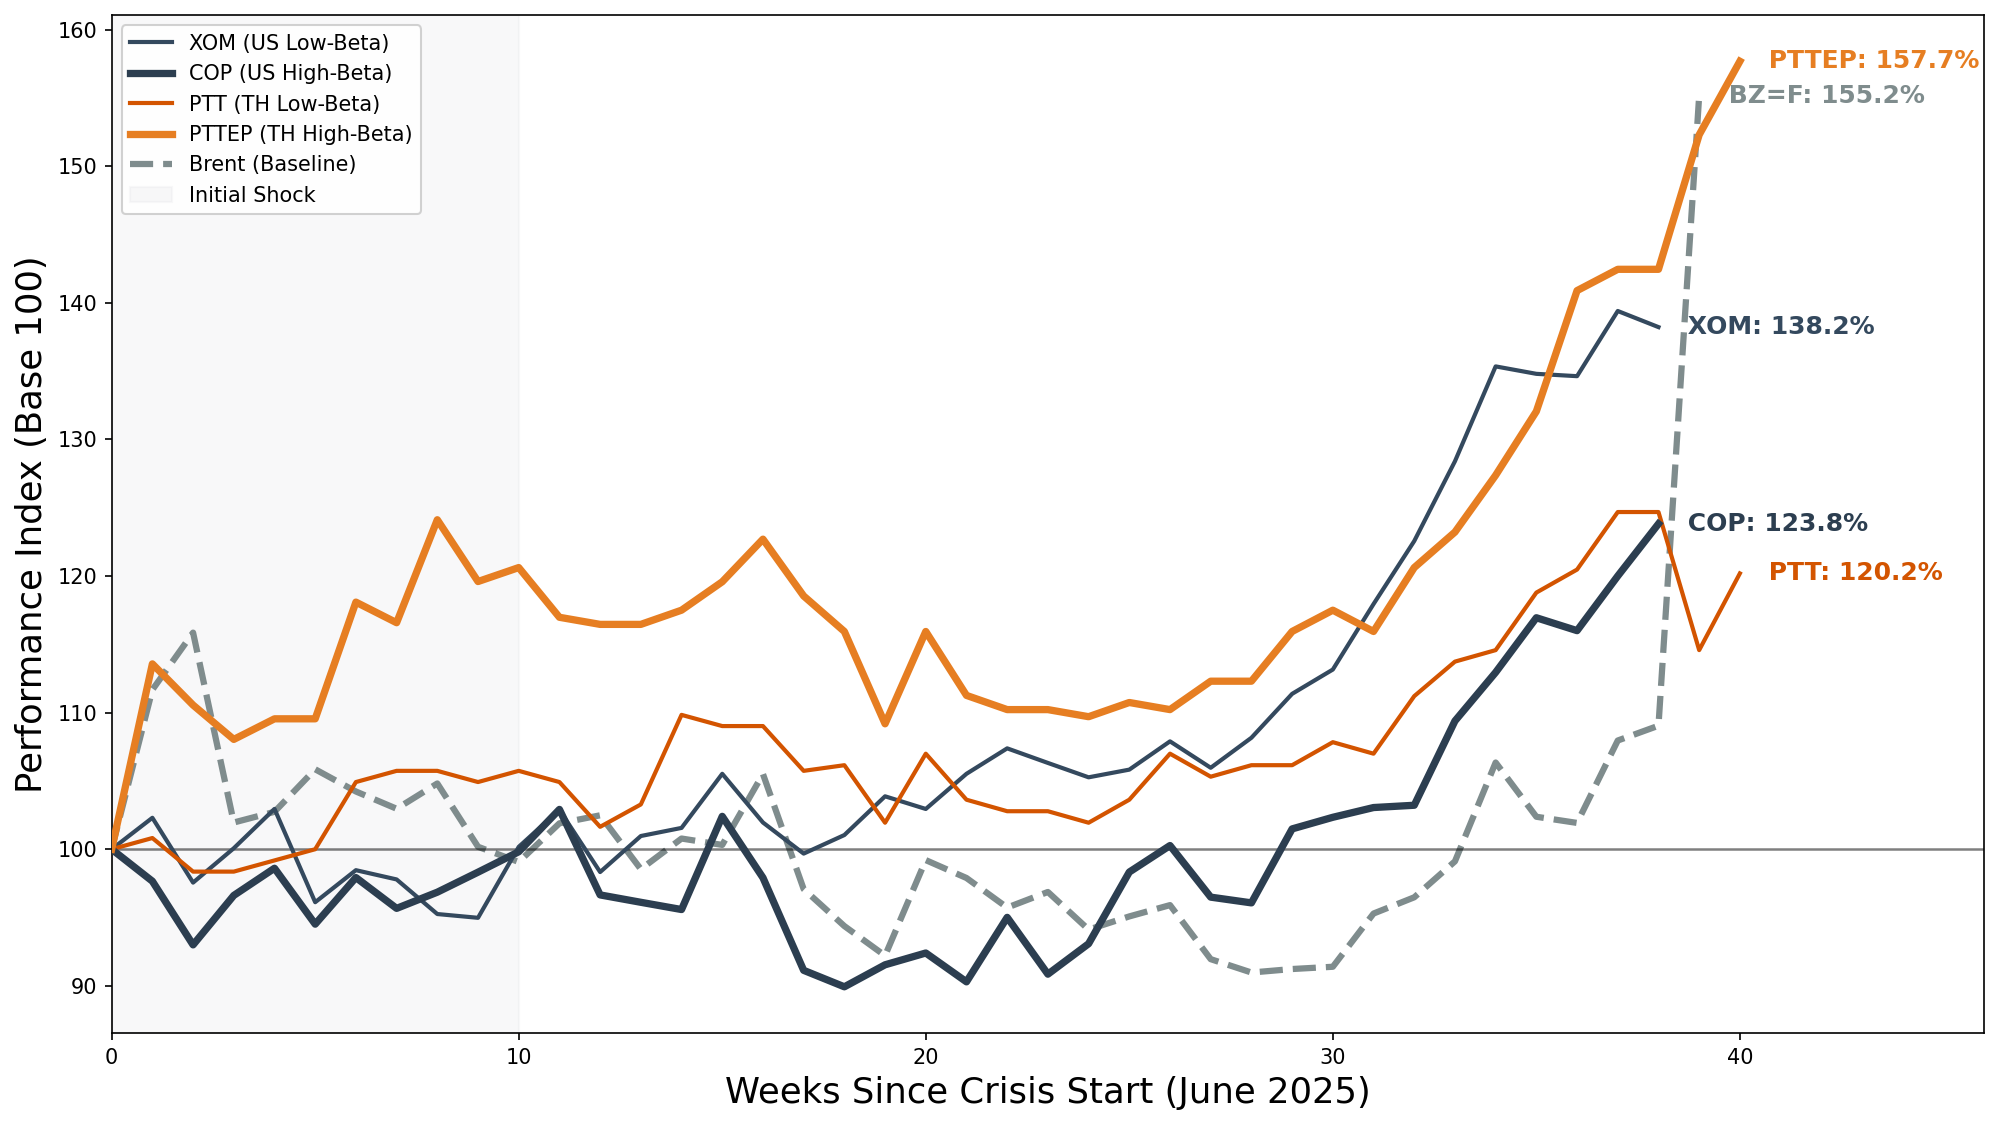

In [34]:
def fig_12_beta_iran(stocks):
    print("\n[Fig 12] Beta Battle: Iran Crisis 2025-26")
    crisis_start = pd.Timestamp("2025-06-01")
    sub = stocks[stocks.index >= crisis_start].copy()
    tickers = ["XOM","COP","PTT.BK","PTTEP.BK","BZ=F"]
    sm = {"BZ=F":('#7F8C8D',3.0,'--',"Brent (Baseline)",2),"COP":('#2C3E50',3.5,'-',"COP (US High-Beta)",5),
          "XOM":('#34495E',2.0,'-',"XOM (US Low-Beta)",4),"PTTEP.BK":('#E67E22',3.5,'-',"PTTEP (TH High-Beta)",5),
          "PTT.BK":('#D35400',2.0,'-',"PTT (TH Low-Beta)",4)}
    fig, ax = plt.subplots(figsize=(15, 8), dpi=150)
    for t in tickers:
        ts=sub[sub["Ticker"]==t]["Close"].dropna().copy()
        if len(ts)<2: continue
        ix=(ts/ts.iloc[0])*100; c,lw,ls,lb,z=sm[t]
        ax.plot(range(len(ix)),ix,color=c,lw=lw,ls=ls,label=lb,zorder=z)
        ax.text(len(ix)-0.5,ix.iloc[-1],f" {t.split('.')[0]}: {ix.iloc[-1]:.1f}%",color=c,va='center',fontweight='bold',fontsize=12,)
    ax.axhline(100,color='black',lw=1.2,alpha=0.5); ax.axvspan(0,10,color='#BDC3C7',alpha=0.1,label="Initial Shock")
    ax.set_xlim(0, len(ix) + 6)
    ax.set_xlabel("Weeks Since Crisis Start (June 2025)",fontsize=17)
    ax.set_ylabel("Performance Index (Base 100)",fontsize=17)
    #style_ax(ax, title="Iran Crisis 2025-26: Beta Sensitivity Masterclass",
    #         subtitle="Comparative Resilience: US Majors vs Thai Energy Leaders",
    #         caption="High-Beta นำขึ้นอีกครั้ง | PTTEP มี correlation กับ Brent spike สูงกว่า XOM", fig_num=12)
    ax.legend(loc="upper left",frameon=True,facecolor='white',framealpha=0.9,fontsize=10)
    plt.tight_layout(rect=[0, 0.05, 0.9, 1]); save_fig(fig, "12_beta_iran"); plt.show()

fig_12_beta_iran(stocks)

#### การวิเคราะห์ Fig 12: Beta Sensitivity ในช่วงวิกฤตอิหร่าน (2025-26)

Event Study ครั้งที่สองนี้ใช้วิธีการเดียวกับ Fig 11 แต่กำหนดจุดเริ่มต้นที่มิถุนายน 2025 (จุดเริ่มวิกฤตอิหร่าน) เพื่อทดสอบว่า Pattern ที่พบในสงครามยูเครนสามารถ Replicate ได้หรือไม่ (Out-of-Sample Test) ผลลัพธ์แสดงว่า Behavioral Pattern เดิมปรากฏขึ้นอีกครั้ง — High-Beta (COP, PTTEP) นำขึ้นเป็นกลุ่มแรก ขณะที่ Low-Beta (XOM, PTT) ขยับตามช้ากว่า

สิ่งที่ต่างจากกรณียูเครนคือ PTTEP แสดง Relative Strength ที่ดีขึ้น ซึ่งอาจอธิบายได้จาก Adaptive Expectation — นักลงทุนเรียนรู้จากวิกฤตก่อนหน้าและเข้าซื้อ High-Beta Thai Upstream เร็วขึ้น (Learning Effect) รวมถึง PTTEP มีสัมปทานในแหล่งผลิตที่ได้รับประโยชน์โดยตรงจากราคาน้ำมันที่สูงขึ้น การซ้ำรอยนี้ยืนยันว่า Supply Shock จากความขัดแย้งด้านภูมิรัฐศาสตร์มี Playbook ที่ค่อนข้างสม่ำเสมอ

**Key Findings:**
- Pattern ของ Supply Shock Crisis มีความ Reproducible — สามารถใช้เป็น Playbook สำหรับวิกฤตในอนาคตได้
- PTTEP แสดง Improvement ในความสามารถ Capture Oil Upside ซึ่งสะท้อน Learning Curve ของตลาด
- การ Confirm Pattern จาก 2 วิกฤตที่ต่างกันเพิ่มความน่าเชื่อถือ (Statistical Robustness) ของข้อสรุป


### Fig 13. Recovery Path Analysis — การเปรียบเทียบความเร็วในการฟื้นตัว



[Fig 13] Multi-Crisis Recovery Analysis
  Saved: outputs/figures\13_recovery_paths.png


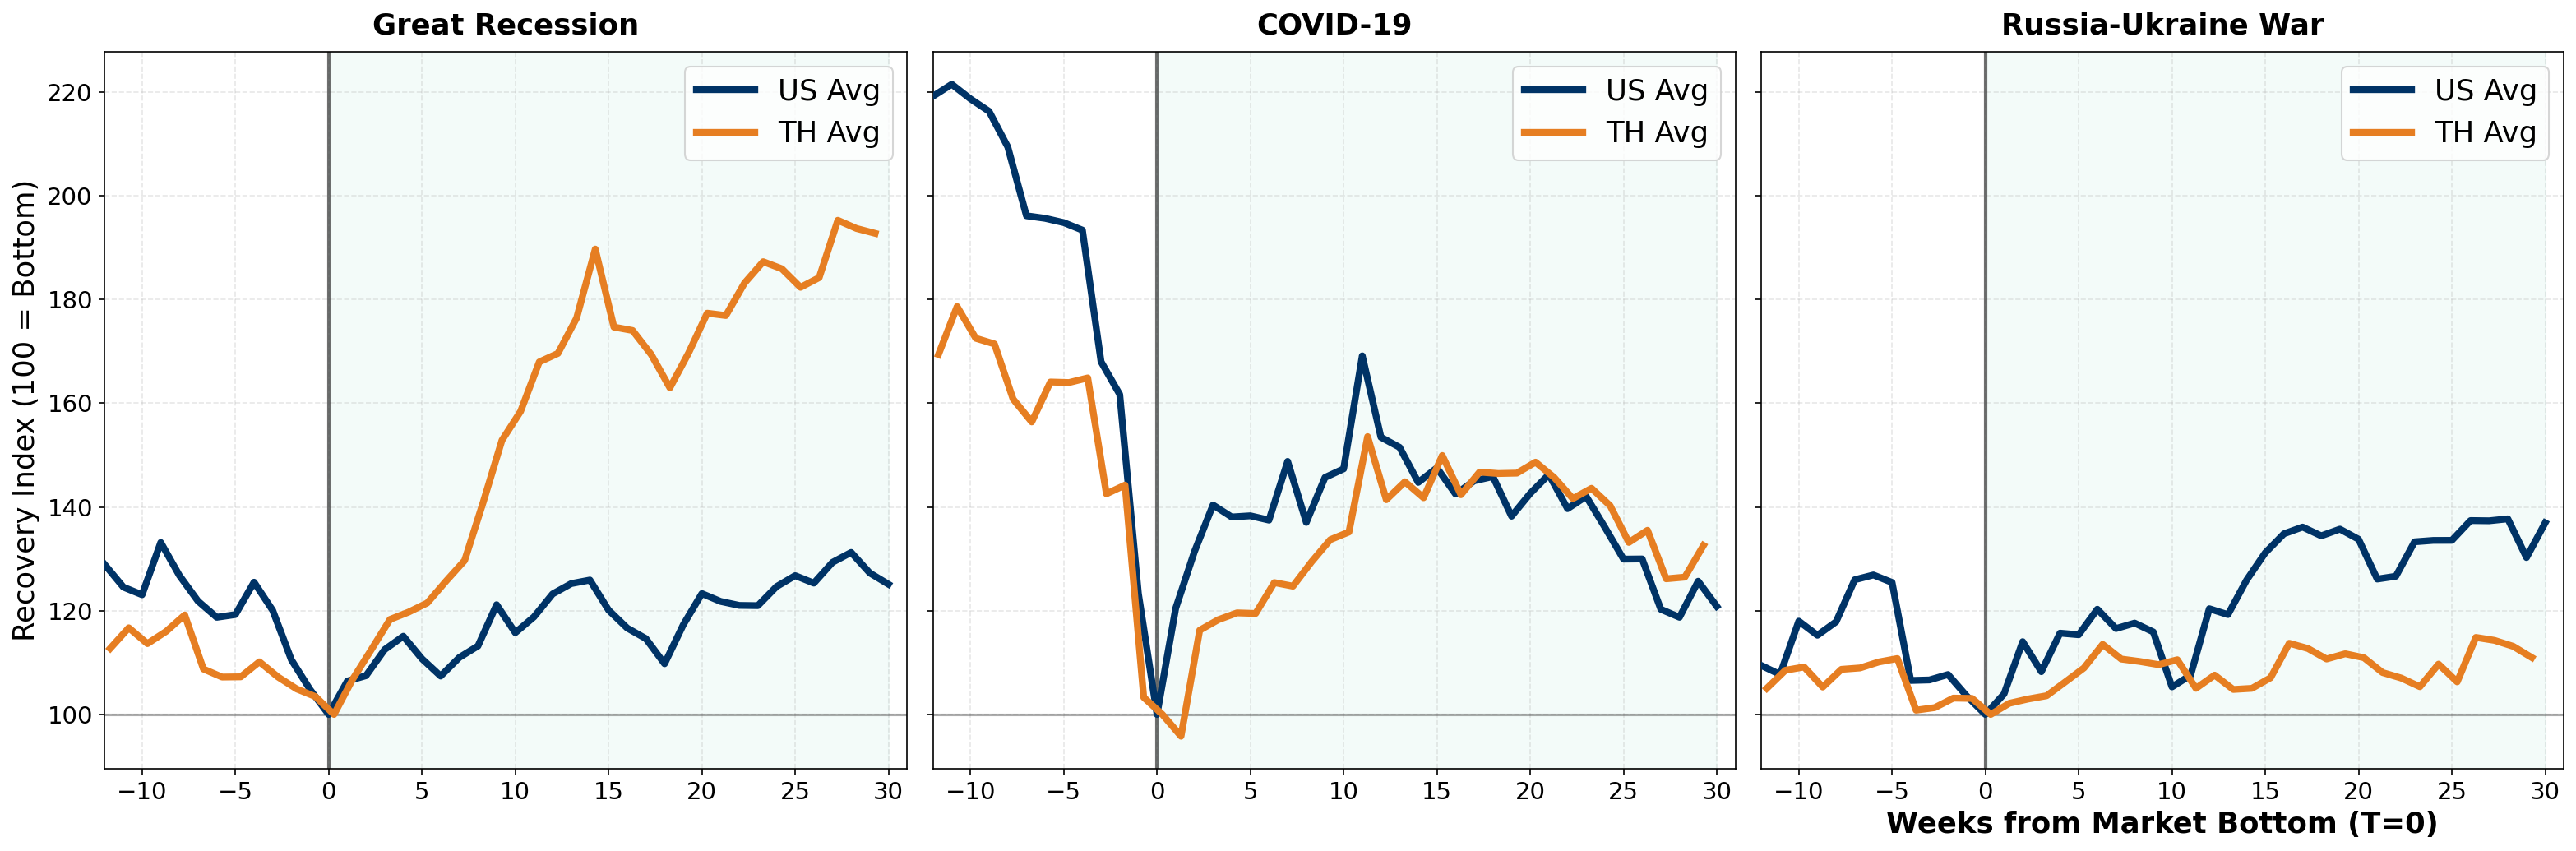

In [35]:
def fig_13_recovery_paths(stocks_df):
    print("\n[Fig 13] Multi-Crisis Recovery Analysis")
    us_tickers = ['XOM','CVX','COP','SHEL','TTE']; th_tickers = ['PTT.BK','PTTEP.BK','PTTGC.BK','BCP.BK','PTG.BK']
    target_crises = ['Great Recession','COVID-19','Russia-Ukraine War']; WB=12; WA=30
    df=stocks_df.copy()
    if 'Date' not in df.columns: df=df.reset_index()
    df['Date']=pd.to_datetime(df['Date'])
    piv=df.pivot_table(index='Date',columns='Ticker',values='Close')
    us_avg_raw=piv[[t for t in us_tickers if t in piv.columns]].mean(axis=1)
    def nvd(s,t):
        v=s.dropna()
        if v.empty: return None
        d=abs(v.index-t); n=v.index[d.argmin()]
        return n if abs((n-t).days)<=7 else None
    fig,axes=plt.subplots(1,len(target_crises),figsize=(7*len(target_crises),7),dpi=150,sharey=True)
    for i,era in enumerate(target_crises):
        ax=axes[i]; ed=df[df['crisis_era']==era]['Date'].unique()
        if len(ed)==0: continue
        eu=us_avg_raw[us_avg_raw.index.isin(ed)].dropna()
        if eu.empty: continue
        tr=eu.idxmin(); ds=tr-pd.Timedelta(weeks=WB); de=tr+pd.Timedelta(weeks=WA)
        mk=(piv.index>=ds)&(piv.index<=de); pd_=piv.index[mk]
        ax.axvspan(0,WA,color='#E8F8F5',alpha=0.5,zorder=0)
        for tks,cm,lb,_ in [(us_tickers,'#003366','US Avg',None),(th_tickers,'#E67E22','TH Avg',None)]:
            bv={}
            for t in tks:
                if t not in piv.columns: continue
                nd=nvd(piv[t],tr)
                if nd and piv[t].loc[nd]!=0: bv[t]=piv[t].loc[nd]
            if bv:
                d2=piv[list(bv.keys())].reindex(pd_)
                nm=(d2/pd.Series(bv)).mean(axis=1).dropna()*100
                if not nm.empty:
                    wn=[(d-tr).days/7 for d in nm.index]
                    ax.plot(wn,nm,color=cm,lw=4,label=lb,zorder=10)
        ax.axvline(0,color='#333',ls='-',lw=2,alpha=0.7); ax.axhline(100,color='#333',lw=1.5,alpha=0.4)
        ax.set_title(f"{era}",fontsize=17,fontweight='bold',pad=10); ax.set_xlim(-WB,WA+1)
        ax.grid(True,ls='--',alpha=0.3); ax.legend(loc='upper right',fontsize=17,frameon=True);ax.tick_params(axis='both', labelsize=14)
        if i==0: ax.set_ylabel("Recovery Index (100 = Bottom)",fontsize=17)
    #plt.suptitle("Fig 13. Strategic Recovery Paths: US vs Thai Energy",fontsize=14,fontweight='bold',y=1.02)
    plt.xlabel("Weeks from Market Bottom (T=0)",fontsize=17,fontweight='bold')
    plt.tight_layout(); save_fig(fig, "13_recovery_paths"); plt.show()

fig_13_recovery_paths(stocks)


#### การวิเคราะห์ Fig 13: Multi-Crisis Recovery Comparison

กราฟ Panel นี้เปรียบเทียบ Recovery Path ของกลุ่ม US vs Thai โดยปรับฐาน 100 ที่จุดต่ำสุด (Trough) ของแต่ละวิกฤต (T=0) แล้วติดตามไปอีก 30 สัปดาห์ วิธีการนี้เป็นมาตรฐานของ Event Study ในทางวิชาการ ที่ช่วยให้เปรียบเทียบ Recovery Speed ข้ามวิกฤตที่มีขนาดและลักษณะต่างกันได้

ข้อค้นพบหลักคือ US Energy มี Recovery Speed ที่สูงกว่า Thai Energy ในทุกวิกฤตที่ศึกษา ปัจจัยหลักที่อธิบายได้แก่ Market Microstructure ที่ต่างกัน — ตลาดหุ้นสหรัฐฯ มี Institutional Ownership สูงกว่า มี Short Selling Mechanism ที่ช่วย Price Discovery และมี Contrarian Capital (เช่น Value Fund, Pension Fund) ที่เข้าซื้อในจังหวะวิกฤตได้รวดเร็วกว่า ขณะที่ตลาดไทยต้องรอจนเข้า Risk-On Regime จริงๆ ก่อนที่เงินต่างชาติจะไหลกลับเข้ามา

**Key Findings:**
- US Energy ฟื้นตัวเร็วกว่า Thai ในทุกกรณี → ถ้าต้องเลือกฝั่งเดียวในช่วง Recovery ข้อมูลเชิงประจักษ์ชี้ไปที่ US
- COVID-19 Recovery เป็น V-Shape (เร็ว) | GFC Recovery เป็น U-Shape (ช้า) → ประเภทวิกฤตกำหนดรูปแบบ Recovery
- Entry Signal ที่เหมาะสมคือ VIX เริ่มลดจากจุดสูงสุด + INDPRO เริ่มฟื้นตัว = สัญญาณที่ Recovery กำลังเริ่มต้น


### Fig 14. Maximum Drawdown — การวัดความเสียหายสูงสุดในแต่ละวิกฤต



[Fig 14] Max Drawdown: The Deepest Wounds
  Saved: outputs/figures\14_max_drawdown.png


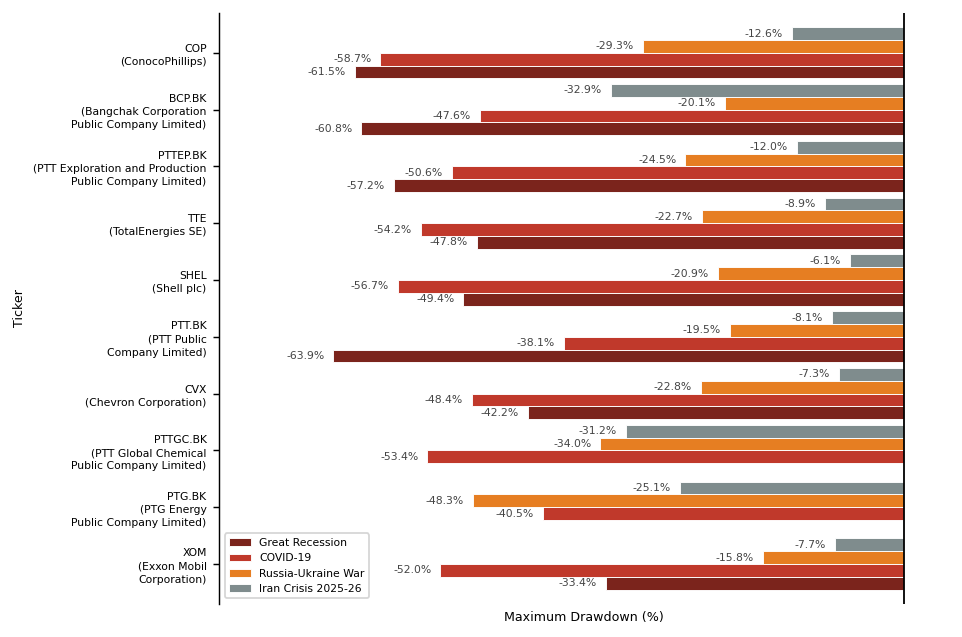

In [36]:
def fig_14_max_drawdown(stocks):
    print("\n[Fig 14] Max Drawdown: The Deepest Wounds")

    crises = ["Great Recession","COVID-19","Russia-Ukraine War","Iran Crisis 2025-26"]
    dd_list=[]

    for era in crises:
        sub=stocks[stocks["crisis_era"]==era]
        for t in ALL_STOCKS:
            ts=sub[sub["Ticker"]==t]["Close"]
            if len(ts)<2:
                dd_list.append({"Ticker":t,"Crisis":era,"Max_Drawdown":0})
                continue
            pk=ts.expanding().max()
            dd=((ts-pk)/pk).min()*100
            dd_list.append({"Ticker":t,"Crisis":era,"Max_Drawdown":dd})

    dd_df=pd.DataFrame(dd_list)

    dd_piv=dd_df.pivot(index="Ticker",columns="Crisis",values="Max_Drawdown")
    dd_piv["Mean_DD"]=dd_piv.mean(axis=1)
    dd_piv=dd_piv.sort_values("Mean_DD",ascending=False).drop(columns="Mean_DD")
    dd_piv=dd_piv[crises]

    # 🔥 ชื่อเต็ม (แบ่ง 2 บรรทัด)
    full_names = {
        "XOM": "(Exxon Mobil\nCorporation)",
        "CVX": "(Chevron Corporation)",
        "COP": "(ConocoPhillips)",
        "TTE": "(TotalEnergies SE)",
        "SHEL": "(Shell plc)",
        "PTT.BK": "(PTT Public\nCompany Limited)",
        "PTTEP.BK": "(PTT Exploration and Production\nPublic Company Limited)",
        "BCP.BK": "(Bangchak Corporation\nPublic Company Limited)",
        "PTG.BK": "(PTG Energy\nPublic Company Limited)",
        "PTTGC.BK": "(PTT Global Chemical\nPublic Company Limited)"
    }

    fig,ax=plt.subplots(figsize=(7.5,5),dpi=130)

    colors=["#7B241C","#C0392B","#E67E22","#7F8C8D"]

    dd_piv.plot.barh(
        ax=ax,
        color=colors,
        width=0.9,
        edgecolor="white",
        linewidth=0.5
    )

    ax.set_xticks([])

    # ✅ รวมชื่อย่อ + ชื่อเต็ม (อยู่ตำแหน่งเดียวกัน)
    yticks = [f"{t}\n{full_names.get(t,'')}" for t in dd_piv.index]
    ax.set_yticklabels(yticks, fontsize=6, linespacing=1.4)

    # value label
    for p in ax.patches:
        w=p.get_width()
        if w<-1:
            ax.text(
                w-1,
                p.get_y()+p.get_height()/2,
                f'{w:.1f}%',
                va='center',
                ha='right',
                fontsize=6,
                color='#444'
            )

    ax.set_ylabel("Ticker",fontsize=7)
    ax.set_xlabel("Maximum Drawdown (%)",fontsize=7)

    ax.axvline(0,color='black',lw=1)

    ax.set_xlim(dd_piv.min().min()*1.2,5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.legend(loc="lower left",frameon=True,facecolor='white',fontsize=6)

    plt.tight_layout()
    save_fig(fig,"14_max_drawdown")
    plt.show()


fig_14_max_drawdown(stocks)

#### การวิเคราะห์ Fig 14: Maximum Drawdown Comparison ข้ามวิกฤต

Maximum Drawdown (MDD) คือการวัดความเสียหายจาก Peak สู่ Trough ที่มากที่สุดในช่วงเวลาหนึ่ง ซึ่งเป็นตัวชี้วัดความเสี่ยงขาลง (Downside Risk Metric) ที่นักลงทุนสถาบันให้ความสำคัญ เนื่องจากสะท้อน "Worst Case ที่เคยเกิดขึ้นจริง" Grouped Horizontal Bar Chart นี้เปรียบเทียบ MDD ของหุ้นพลังงานแต่ละตัวใน 4 วิกฤตสำคัญ

Great Recession (สีแดงเข้ม) สร้าง MDD รุนแรงที่สุด — หุ้นหลายตัวมี Drawdown เกิน 60% สะท้อนความเสียหายที่รุนแรงเมื่อเกิด Systemic Risk ที่ลุกลามจากภาคการเงินสู่ภาคเศรษฐกิจจริง COVID-19 สร้าง Drawdown ที่รุนแรงสำหรับหุ้น US มากกว่า Thai เนื่องจาก Valuation ของหุ้น US สูงกว่าจึงมี "ระยะทางร่วง" มากกว่า ในทางตรงข้าม วิกฤตอิหร่าน (สีเทา) สร้าง MDD ที่เบาที่สุด ซึ่งอาจสะท้อน Market Learning Effect ที่นักลงทุนมีประสบการณ์จัดการวิกฤตด้านภูมิรัฐศาสตร์ดีขึ้น

**Key Findings:**
- GFC MDD > 60% ควรใช้เป็น Stress Test Scenario มาตรฐานสำหรับพอร์ตพลังงาน
- หุ้นที่มี MDD < 30% ในทุกวิกฤต แสดง Balance Sheet Resilience ที่โดดเด่น → สมควรได้รับ Premium Weight
- Position Sizing Rule: Max Acceptable Loss ÷ Historical MDD = Maximum Allocation Percentage


---
# Part 5: Strategic Allocation Framework
### การสังเคราะห์ผลวิเคราะห์สู่กรอบการจัดสรรการลงทุน

ส่วนสุดท้ายจะสังเคราะห์ข้อค้นพบจาก 14 กราฟก่อนหน้าเป็น กรอบยุทธศาสตร์การจัดสรรการลงทุน (Strategic Allocation Framework) ที่ครอบคลุม 4 มิติ ได้แก่ การเลือกระดับ Beta ที่สอดคล้องกับ Risk Tolerance, การวิเคราะห์ Wealth Creation Power ในระยะยาว, ประสิทธิภาพการลงทุนผ่าน Sharpe Ratio, และแผนที่ Risk-Return Frontier


### Fig 15. Beta Selection Framework — COP (Aggressive) vs PTTEP (Defensive)



[Fig 15] Upstream Beta: COP vs PTTEP
  Saved: outputs/figures\15_beta_selection.png


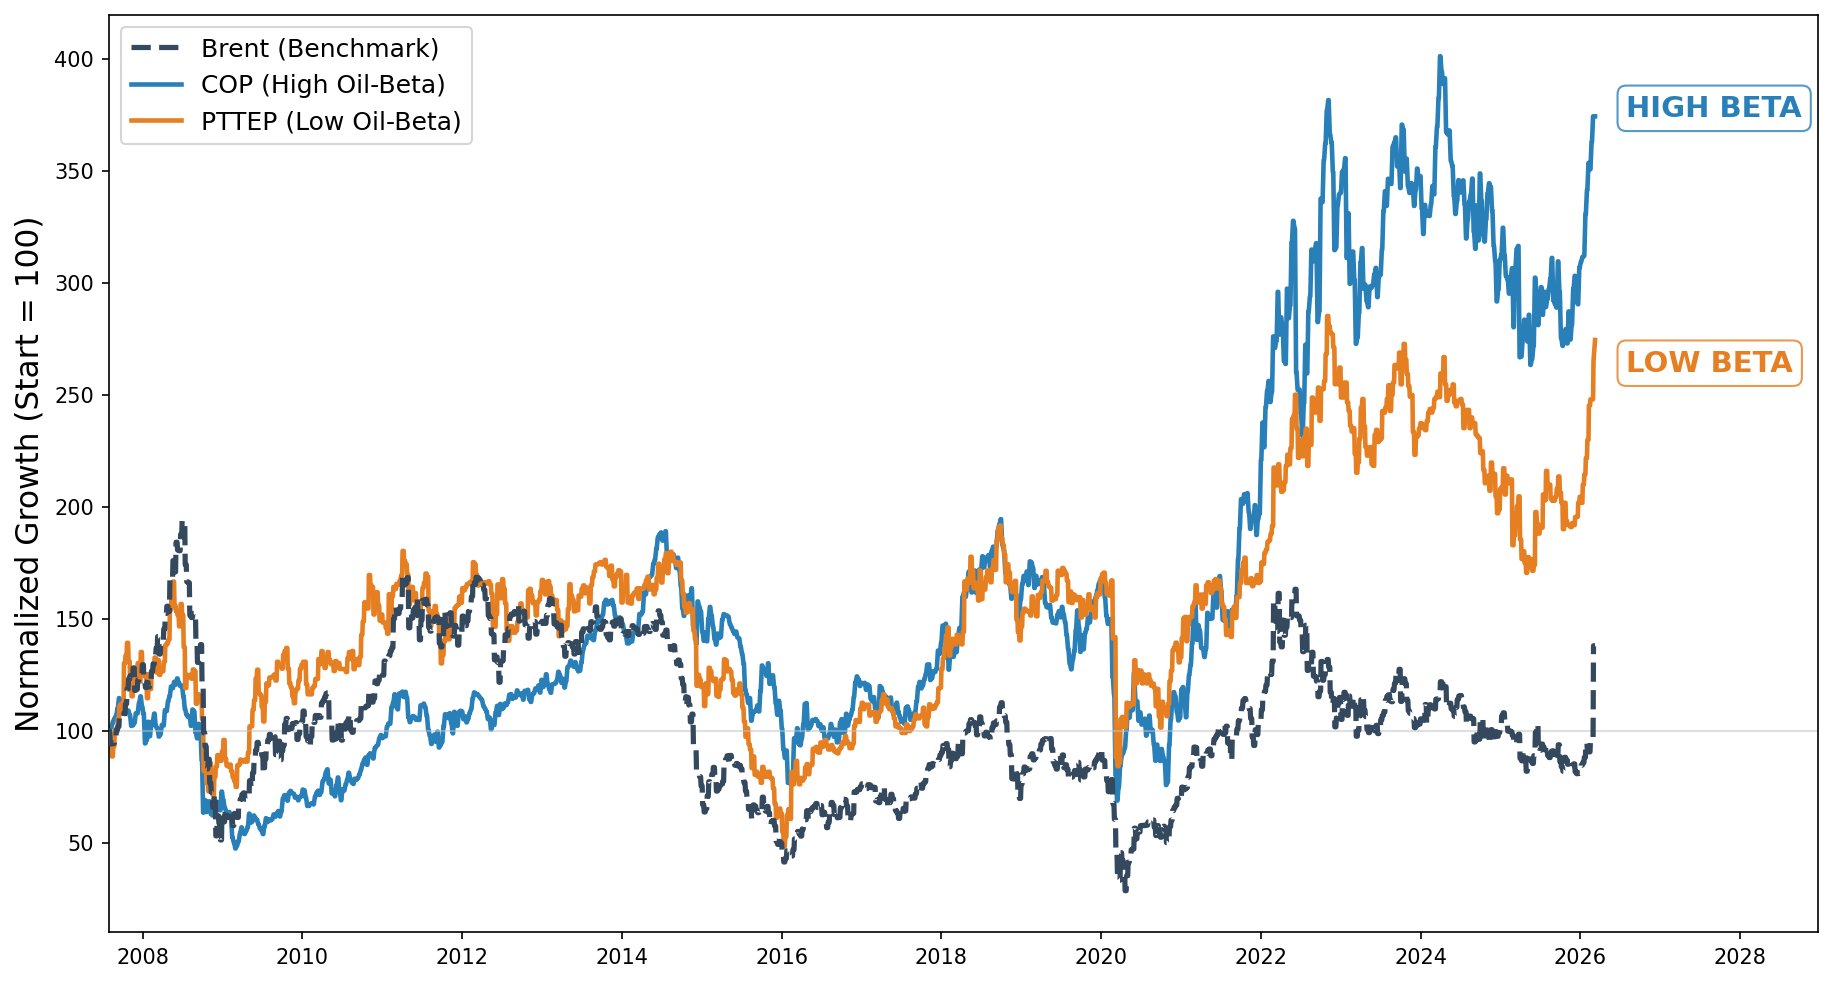

In [37]:
def fig_15_beta_selection(stocks):
    print("\n[Fig 15] Upstream Beta: COP vs PTTEP")
    try:
        tickers=["PTTEP.BK","COP","BZ=F"]; raw=pivot_close(stocks,tickers)
        raw.columns=['Brent_Crude','COP_US','PTTEP_TH']
        al=raw.dropna().copy()
        if al.empty: return
        ix=(al/al.iloc[0])*100
        
        fig,ax=plt.subplots(figsize=(14,7),dpi=150)
        
        # --- วาดกราฟ ---
        ax.plot(ix.index,ix["Brent_Crude"],color='#34495E',lw=2.5,ls='--',label="Brent (Benchmark)",zorder=3)
        ax.plot(ix.index,ix["COP_US"],color='#2980B9',lw=2.2,label="COP (High Oil-Beta)",zorder=2)
        ax.plot(ix.index,ix["PTTEP_TH"],color='#E67E22',lw=2.2,label="PTTEP (Low Oil-Beta)",zorder=2)
        
        # --- ตั้งค่าแกน X ให้ห่างทีละ 2 ปี ---
        ax.xaxis.set_major_locator(mdates.YearLocator(2)) ### 2. กำหนดให้แสดงทุก 2 ปี ###
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y')) ### 3. จัดรูปแบบให้โชว์แค่เลขปี ###
        
        # --- ส่วนอื่นๆ คงเดิม ---
        ld=ix.index[-1]
        ax.annotate('HIGH BETA',xy=(ld,ix["COP_US"].iloc[-1]),xytext=(15,0),textcoords='offset points',fontsize=14,
                    fontweight='bold',color='#2980B9',bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='#2980B9',alpha=0.8))
        ax.annotate('LOW BETA',xy=(ld,ix["PTTEP_TH"].iloc[-1]),xytext=(15,-15),textcoords='offset points',fontsize=14,
                    fontweight='bold',color='#E67E22',bbox=dict(boxstyle='round,pad=0.3',fc='white',ec='#E67E22',alpha=0.8))
        
        ax.axhline(100,color='#BDC3C7',lw=1,alpha=0.5)

        time_range = ix.index[-1] - ix.index[0]
        ax.set_xlim(ix.index[0], ix.index[-1] + (time_range * 0.15))

        ax.set_ylabel("Normalized Growth (Start = 100)",fontsize=15)
        ax.legend(loc="upper left",frameon=True,facecolor='white',fontsize=12)
        
        plt.tight_layout(rect=[0, 0.05, 0.88, 1]) 
        save_fig(fig,"15_beta_selection")
        plt.show()
    except Exception as e: print(f"❌ Error: {e}")
fig_15_beta_selection(stocks)

#### การวิเคราะห์ Fig 15: Oil-Beta ในฐานะเกณฑ์การคัดเลือกหุ้น

กราฟ Indexed Performance นี้เปรียบเทียบ COP กับ PTTEP โดยมี Brent Crude เป็น Benchmark ทำให้มองเห็น "Oil-Beta" ของแต่ละตัวอย่างชัดเจน COP มี Beta > 1 ต่อ Brent (ขยายการเคลื่อนไหวทั้งขาขึ้นและขาลง) ขณะที่ PTTEP มี Beta < 1 (เคลื่อนไหวพอประมาณกว่า)

การเลือก Beta ไม่ใช่คำถามเรื่อง "ถูก-ผิด" แต่เป็นเรื่อง Risk Tolerance Alignment — ผู้ลงทุนที่มี Time Horizon ยาว สามารถรับ Drawdown มากกว่า 40% ได้ และมีมุมมองเชิงบวกต่อ Oil Supercycle ควรพิจารณา COP (Aggressive Allocation) ในทางตรงข้าม ผู้ลงทุนที่ต้องการ Stable Income, รับ Volatility ได้จำกัด หรือต้องการ Energy Exposure โดยไม่รับความเสี่ยงมากเกินไป ควรพิจารณา PTTEP (Defensive Allocation) ทั้งนี้ พอร์ตที่ผสม Beta หลายระดับ (Blended Beta Portfolio) มักให้ Risk-Adjusted Return ที่ดีกว่าการเลือกเพียงระดับเดียว

**Key Findings:**
- High Oil-Beta (COP) เหมาะสำหรับ Tactical/Thematic Allocation ที่มุ่งเน้น Oil Price Exposure
- Low Oil-Beta (PTTEP) เหมาะเป็น Core Holding ที่ให้ทั้ง Capital Appreciation และ Dividend อย่างพอประมาณ
- Blended Portfolio (เช่น 40% COP + 30% PTTEP + 30% PTG) ช่วย Optimize Risk-Adjusted Return


### Fig 16. Cumulative Wealth Creation — การเปรียบเทียบพลังทบต้นระยะยาว



[Fig 16] Wealth Creation Power
  Saved: outputs/figures\16_wealth_creation.png


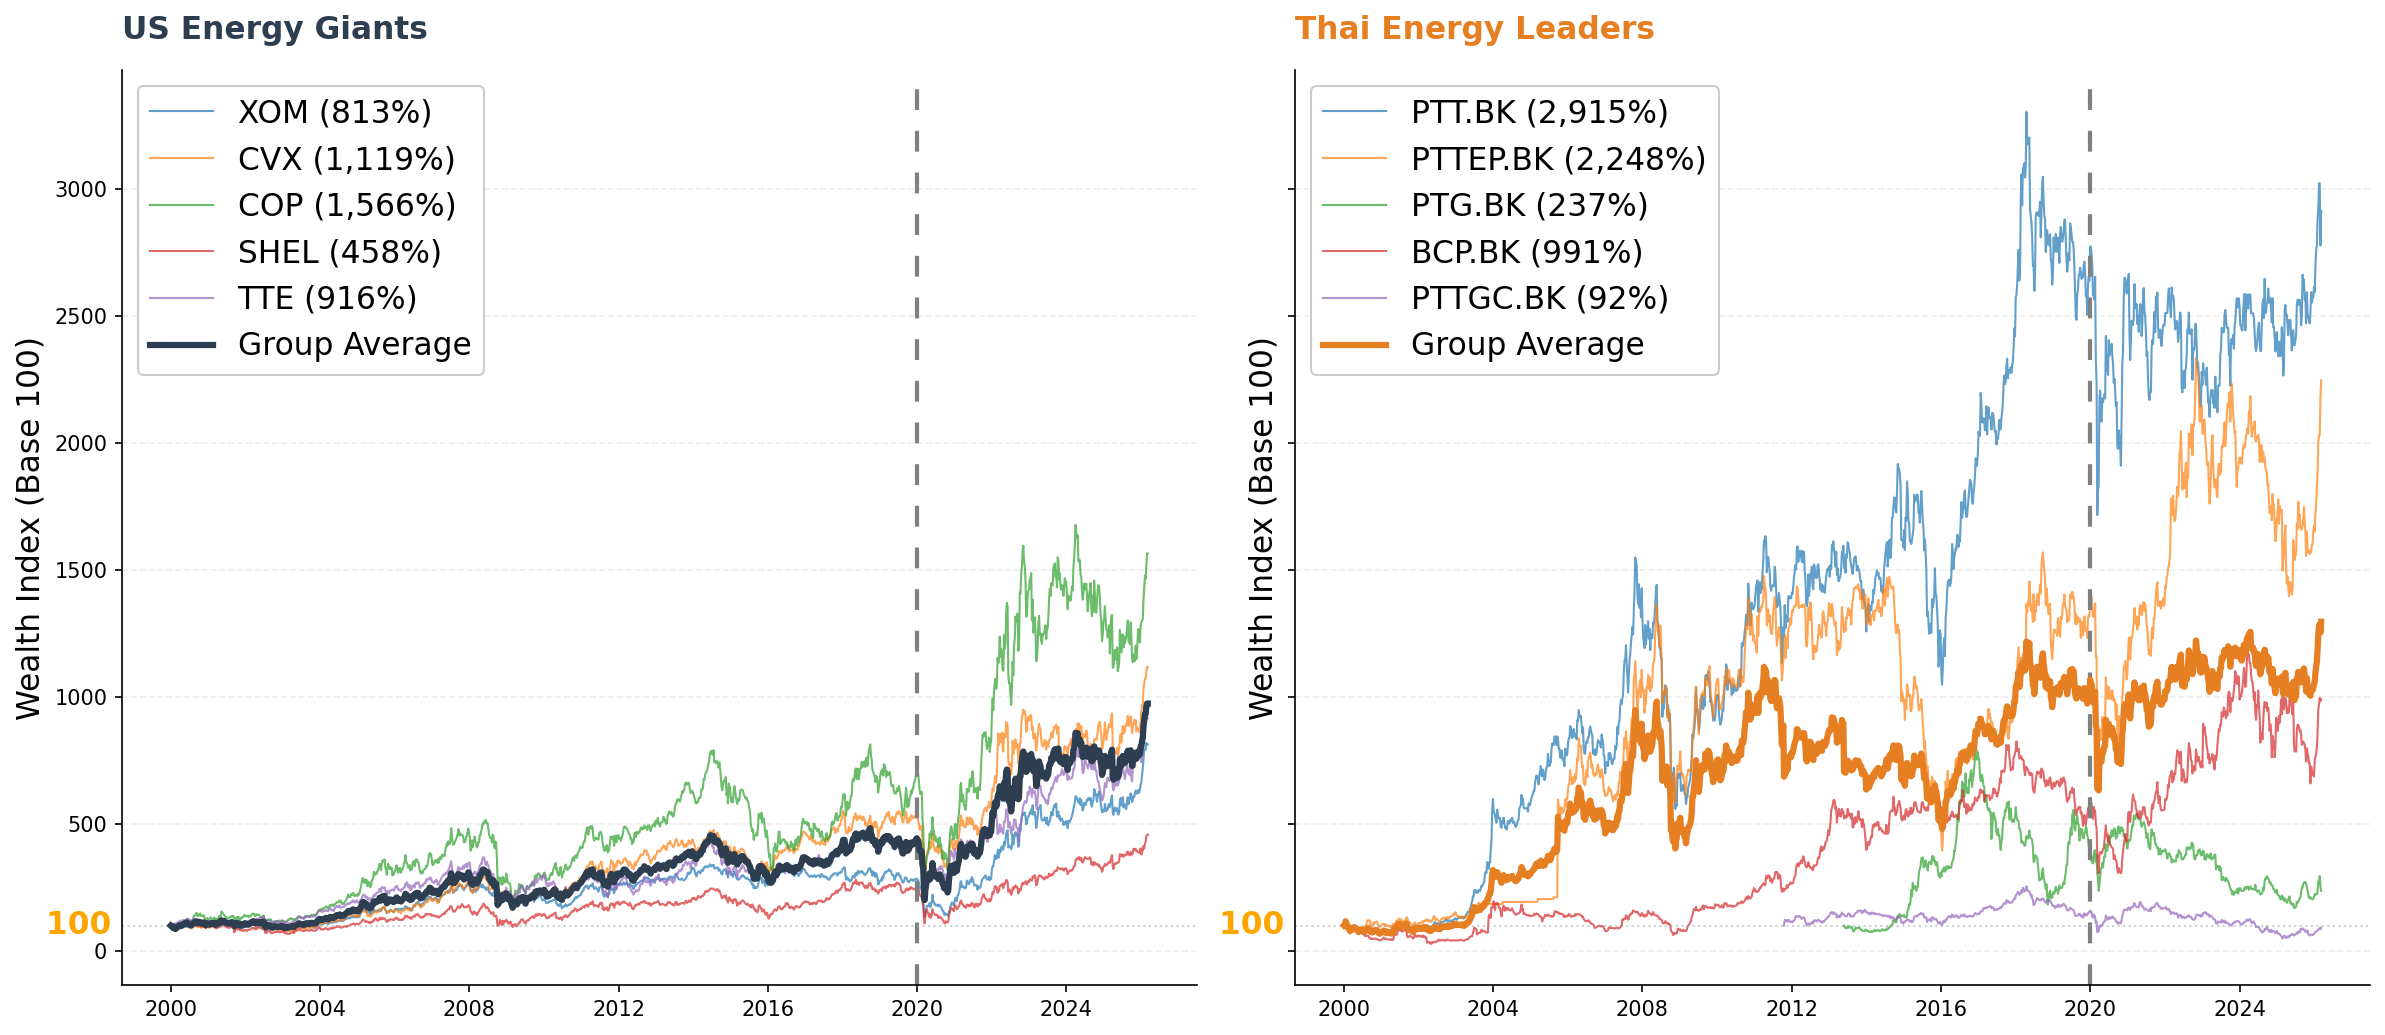

In [38]:
def fig_16_wealth_creation(stocks):
    print("\n[Fig 16] Wealth Creation Power")
    groups=[(US_TICKERS,"US Energy Giants",'#2C3E50'),(TH_TICKERS,"Thai Energy Leaders",'#E67E22')]
    fig,axes=plt.subplots(1,2,figsize=(16,7),sharey=True,dpi=150)
    for i,(tks,title,color) in enumerate(groups):
        ax=axes[i]; all_cum=[]
        for t in tks:
            sub=stocks[stocks["Ticker"]==t].copy()
            if sub.empty: continue
            sub['Date']=pd.to_datetime(sub.get('Date',sub.index)); sub=sub.set_index('Date').sort_index()
            cr=(1+sub["Weekly_Return"].fillna(0)).cumprod()*100; fv=cr.iloc[-1]; all_cum.append(cr)
            ax.plot(cr.index,cr,lw=1,alpha=0.7,label=f"{t} ({fv:,.0f}%)")
        
        if all_cum:
            ga=pd.concat(all_cum,axis=1).mean(axis=1)
            ax.plot(ga.index,ga,lw=3,color=color,label="Group Average",zorder=5)
        
        # เพิ่มเส้นประปี 2020
        ax.axvline(pd.Timestamp('2020-01-01'), color='gray', linestyle='--', lw=2, alpha=1, dashes=(5, 5))
        
        ax.set_title(title,fontsize=15,fontweight="bold",color=color,loc="left",pad=15)
        ax.legend(frameon=True,fontsize=15,loc="upper left",facecolor='white',framealpha=1)
        ax.set_ylabel("Wealth Index (Base 100)",fontsize=15)
        
        # เส้นประแนวนอน Base 100 และตัวเลข 100
        ax.axhline(100,color='#95A5A6',ls=':',lw=1,alpha=0.5)
        ax.text(ax.get_xlim()[0], 100, '100 ', va='center', ha='right', fontsize=15, color='orange', fontweight='bold')

        for s in ["top","right"]: ax.spines[s].set_visible(False)
        ax.grid(axis='y',linestyle='--',alpha=0.2)
    #plt.suptitle("Fig 16. Wealth Creation: US Giants vs Thai Energy (2000-2026)",fontsize=14,fontweight="bold",y=1.02)
    plt.tight_layout(); save_fig(fig,"16_wealth_creation"); plt.show()

fig_16_wealth_creation(stocks)


#### การวิเคราะห์ Fig 16: Long-term Wealth Accumulation Comparison

Split Panel Chart นี้แสดง Cumulative Wealth Index (ฐาน 100) ของหุ้นพลังงานแต่ละตัว โดยแบ่งเป็น US Energy (แผงซ้าย) และ Thai Energy (แผงขวา) เส้นหนา (Group Average) แสดงผลตอบแทนของ Equal-Weighted Portfolio ที่ถือหุ้นทุกตัวในกลุ่มด้วยน้ำหนักเท่ากัน

ผลลัพธ์แสดงว่ากลุ่ม US Energy สร้าง Wealth ได้มากกว่ากลุ่ม Thai อย่างมีนัยสำคัญในระยะยาว ปัจจัยที่อธิบายได้แก่ Capital Efficiency ที่สูงกว่า (วัดจาก ROIC), Shareholder Return Policy ที่เน้น Buyback + Dividend Growth, การเข้าถึงแหล่ง Reserves ระดับโลก, และ Valuation Re-rating จากนักลงทุนสถาบันทั่วโลก เส้น Group Average ยังแสดง "Diversification Benefit ภายในกลุ่ม" — แม้หุ้นบางตัวจะ Underperform แต่ค่าเฉลี่ยยังคงแสดง Upward Trend ที่สม่ำเสมอ ซึ่งสะท้อนพลังของ Portfolio Effect

**Key Findings:**
- US Energy สร้าง Wealth ได้มากกว่า Thai ในระยะยาว เนื่องจาก Capital Efficiency และ Market Premium ที่สูงกว่า
- Compounding ทำงานได้ดีที่สุดเมื่อไม่ขายในจังหวะวิกฤต — การ Panic Sell ทำลาย Compounding Power อย่างถาวร
- Equal-Weighted Portfolio + Annual Rebalancing เป็นกลยุทธ์ที่เรียบง่ายแต่ให้ผลลัพธ์ที่แข็งแกร่ง


### Fig 17. Sharpe Ratio Heatmap — ประสิทธิภาพการลงทุนต่อหน่วยความเสี่ยงในแต่ละยุค



[Fig 17] Sharpe Ratio Heatmap
  Saved: outputs/figures\17_sharpe_heatmap_with_periods.png


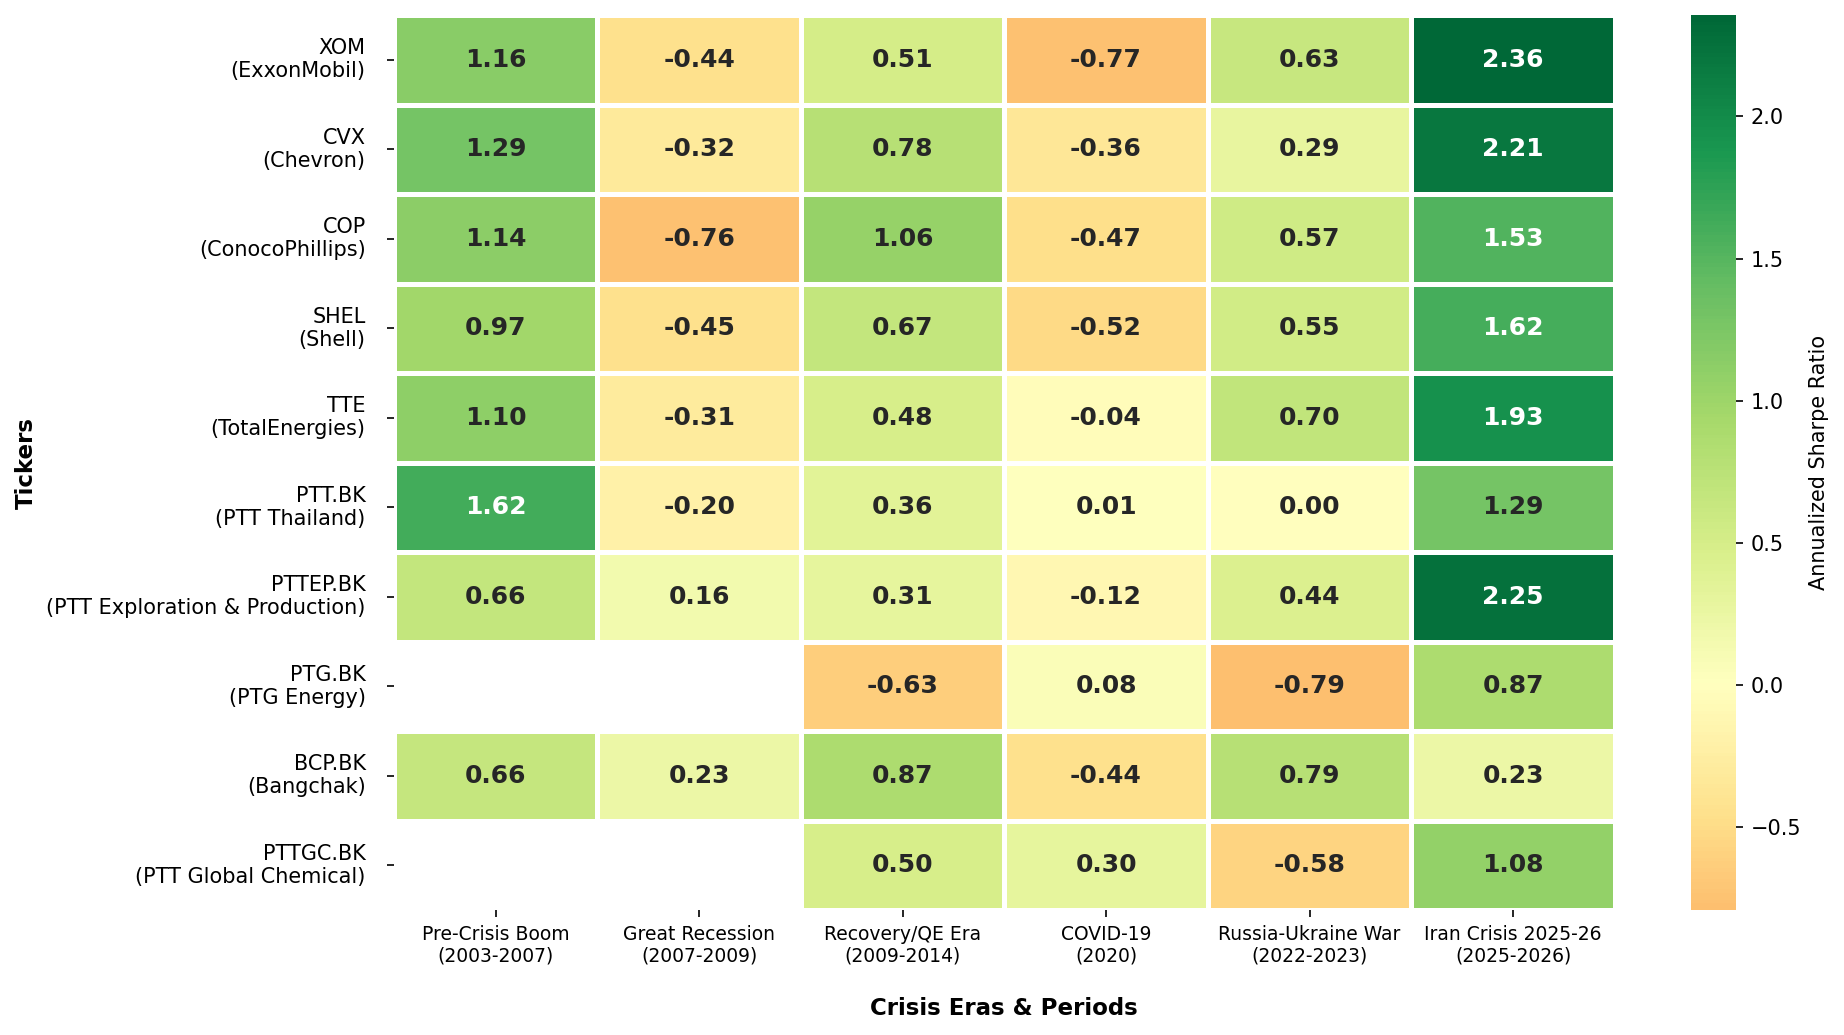

In [39]:
def fig_17_sharpe_heatmap(stocks):
    print("\n[Fig 17] Sharpe Ratio Heatmap")
    
    # 1. รายชื่อยุคแบบเดิม (เพื่อใช้ดึงข้อมูลจาก DataFrame)
    eras_raw = ["Pre-Crisis Boom", "Great Recession", "Recovery/QE Era", 
                "COVID-19", "Russia-Ukraine War", "Iran Crisis 2025-26"]
    
    # 2. รายชื่อยุคแบบใหม่ที่จะให้โชว์บนแกน X
    eras_display = [
        "Pre-Crisis Boom\n(2003-2007)", 
        "Great Recession\n(2007-2009)", 
        "Recovery/QE Era\n(2009-2014)", 
        "COVID-19\n(2020)", 
        "Russia-Ukraine War\n(2022-2023)", 
        "Iran Crisis 2025-26\n(2025-2026)"
    ]
    
    rf = 0.03/52
    results = []
    
    # ตรวจสอบ Tickers
    tickers_to_use = ALL_STOCKS if 'ALL_STOCKS' in locals() or 'ALL_STOCKS' in globals() else stocks['Ticker'].unique()
    
    # วนลูปดึงข้อมูลโดยใช้ชื่อยุคแบบเดิม (eras_raw)
    for era in eras_raw:
        sub = stocks[stocks["crisis_era"] == era]
        for t in tickers_to_use:
            rets = sub[sub["Ticker"] == t]["Weekly_Return"].dropna()
            if len(rets) < 10: continue
            std_val = rets.std()
            if std_val > 0:
                sr = (rets.mean() - rf) / std_val * np.sqrt(52)
                results.append({"Ticker": t, "Crisis": era, "Sharpe": sr})      
    
    sr_df = pd.DataFrame(results)
    if sr_df.empty:
        print("No data available to plot.")
        return

    # สร้าง Pivot Table
    sr_piv = sr_df.pivot(index="Ticker", columns="Crisis", values="Sharpe")
    
    # จัดลำดับคอลัมน์ให้ตรงตาม eras_raw ก่อน
    ordered_tickers = [t for t in tickers_to_use if t in sr_piv.index]
    sr_piv = sr_piv.reindex(index=ordered_tickers, columns=eras_raw)

    # --- จุดสำคัญ: เปลี่ยนชื่อคอลัมน์จากชื่อเดิม เป็นชื่อแบบมีวงเล็บปี ---
    sr_piv.columns = eras_display 

    # Mapping ชื่อเต็มแกน Y (เหมือนเดิม)
    full_names = {
        "BZ=F": "BZ=F\n(Brent Oil)","XOM": "XOM\n(ExxonMobil)","CVX": "CVX\n(Chevron)","COP": "COP\n(ConocoPhillips)",
        "PTT.BK": "PTT.BK\n(PTT Thailand)","PTTEP.BK": "PTTEP.BK\n(PTT Exploration & Production)","PTTGC.BK": "PTTGC.BK\n(PTT Global Chemical)",
        "SHEL": "SHEL\n(Shell)","TTE": "TTE\n(TotalEnergies)","PTG.BK": "PTG.BK\n(PTG Energy)","BCP.BK": "BCP.BK\n(Bangchak)"}
    sr_piv.index = [full_names.get(t, t) for t in sr_piv.index]

    # วาดกราฟ
    fig, ax = plt.subplots(figsize=(13, 7), dpi=150) # ปรับขนาดกว้างขึ้นเล็กน้อย
    sns.heatmap(sr_piv, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax, 
                linewidths=1.5, linecolor='white',
                cbar_kws={"label": "Annualized Sharpe Ratio"}, 
                annot_kws={"size": 12, "weight": "bold"})

    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, va='center', rotation=0)
    ax.tick_params(axis='y', pad=10)
    ax.set_xlabel("Crisis Eras & Periods", fontsize=11, fontweight='bold', labelpad=15)
    ax.set_ylabel("Tickers", fontsize=11, fontweight='bold')
    
    plt.xticks(rotation=0, ha='center', fontsize=9) # ปรับ rotation เป็น 0 เพื่อให้อ่านช่วงเวลาได้ง่าย
    plt.tight_layout()   
    
    # บันทึกและแสดงผล
    if 'save_fig' in globals():
        save_fig(fig, "17_sharpe_heatmap_with_periods")
    else:
        plt.savefig("17_sharpe_heatmap.png", bbox_inches='tight')
        
    plt.show()

# เรียกใช้งาน
fig_17_sharpe_heatmap(stocks)

#### การวิเคราะห์ Fig 17: Risk-Adjusted Efficiency ผ่าน Sharpe Ratio

Heatmap นี้แสดง Annualized Sharpe Ratio ของหุ้นพลังงานทุกตัวใน 6 ยุคสำคัญ โดย Sharpe Ratio คำนวณจากสูตร (Annualized Return - Risk-Free Rate) / Annualized Volatility ซึ่งเป็นมาตรวัด Risk-Adjusted Return ที่ใช้กันแพร่หลายในทางวิชาการและอุตสาหกรรมการลงทุน เกณฑ์ตัดสิน: Sharpe > 1.0 = ยอดเยี่ยม, 0.5-1.0 = ดี, < 0 = ผลตอบแทนต่ำกว่าอัตราปลอดความเสี่ยง

Pattern ที่ชัดเจนจาก Heatmap คือ Great Recession เป็น "Red Zone" ที่แทบทุกตัวมี Sharpe ติดลบ — สะท้อนว่าเมื่อเกิด Systemic Risk ไม่มีหุ้นพลังงานตัวใดให้ผลตอบแทนที่คุ้มค่ากับความเสี่ยง ในทางตรงข้าม Russia-Ukraine War Period เป็น "Green Zone" สำหรับ US Upstream (COP, XOM) ที่ให้ Sharpe > 1.0 เพราะราคาน้ำมันพุ่งขึ้นด้วย Realized Volatility ที่ต่ำกว่า GFC ข้อสรุปคือ Supply Shock สร้างสภาพแวดล้อมที่ให้ Risk-Adjusted Return ดี ขณะที่ Systemic Crisis ทำลายทุกตัว

**Key Findings:**
- Sharpe > 1.0 ควรเป็นเป้าหมายในการคัดเลือกหุ้น → ใช้ Heatmap นี้เป็นข้อมูลอ้างอิงในการจัดสรร
- Systemic Risk (GFC) ไม่มีที่หลบในกลุ่มพลังงาน → ต้องใช้ Cross-Asset Hedging (เช่น Gold, Treasuries)
- US Upstream มี Sharpe ดีกว่า Thai ในเกือบทุกยุค → ยืนยัน Alpha ของตลาดสหรัฐฯ ในเชิง Risk-Adjusted


### Fig 18. Risk-Return Frontier — แผนที่ยุทธศาสตร์การจัดสรรในภาวะสงคราม



[Fig 18] War-Time Strategic Frontier
  Saved: outputs/figures\18_strategic_frontier.png


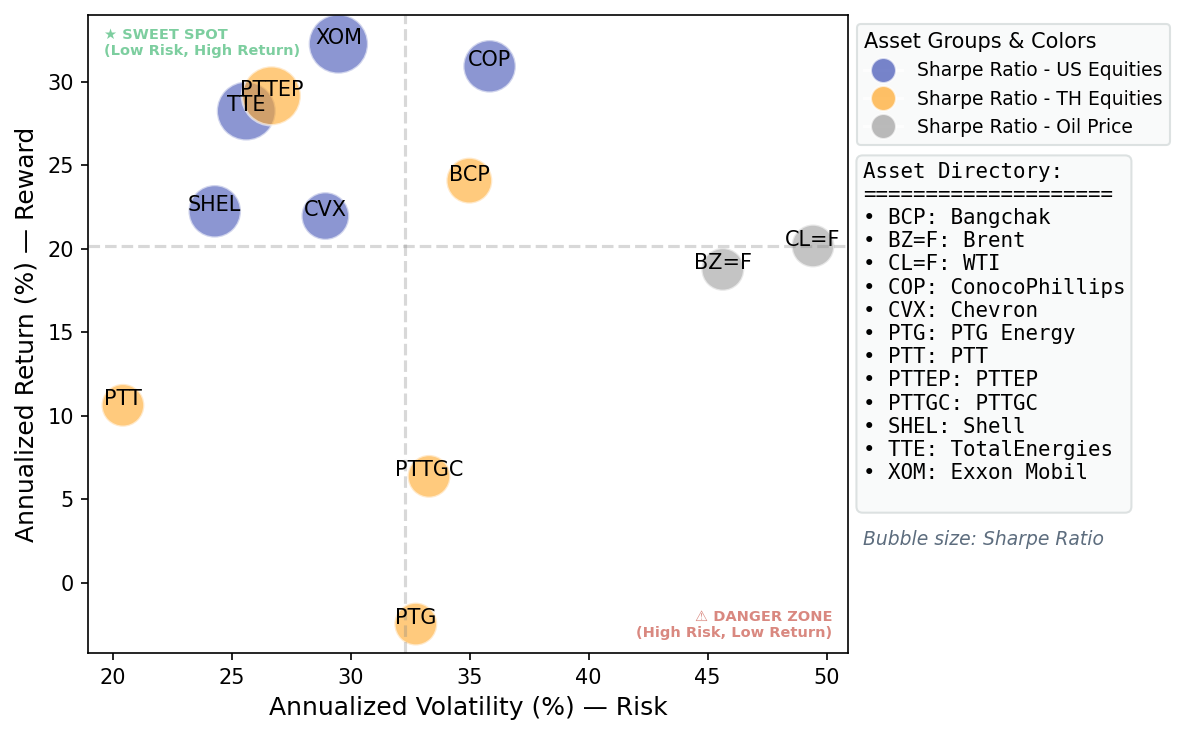

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def fig_18_strategic_frontier(stocks):
    print("\n[Fig 18] War-Time Strategic Frontier")
    try:
        from adjustText import adjust_text; HA=True
    except ImportError:
        try:
            from adjust_text import adjust_text; HA=True
        except ImportError: HA=False
    war_eras=["Russia-Ukraine War","Iran Crisis 2025-26"]; rf=0.04
    cn={"BZ=F":"Brent","CL=F":"WTI","XOM":"Exxon Mobil","CVX":"Chevron","COP":"ConocoPhillips",
        "SHEL":"Shell","TTE":"TotalEnergies","PTT.BK":"PTT","PTTEP.BK":"PTTEP",
        "PTTGC.BK":"PTTGC","BCP.BK":"Bangchak","PTG.BK":"PTG Energy"}
    results=[]
    for t in stocks['Ticker'].unique():
        sub=stocks[(stocks["Ticker"]==t)&(stocks["crisis_era"].isin(war_eras))]
        rets=sub["Weekly_Return"].dropna()
        if len(rets)<8: continue
        ar=rets.mean()*52*100; av=rets.std()*np.sqrt(52)*100; sr=(rets.mean()*52-rf)/(rets.std()*np.sqrt(52))
        results.append({"Ticker":t,"Ann_Return":ar,"Ann_Vol":av,"Sharpe":sr})
    res=pd.DataFrame(results)
    fig,ax=plt.subplots(figsize=(10,5),dpi=150)
    def gc(t):
        if t in ["BZ=F","CL=F"]: return "#9e9e9e"
        return "#3f51b5" if ".BK" not in t else "#ffa726"
    res['Color']=res['Ticker'].apply(gc)
    ax.scatter(res["Ann_Vol"],res["Ann_Return"],s=res["Sharpe"].clip(lower=0.5)*850,c=res["Color"],alpha=0.6,edgecolors='white',linewidths=1.2)
    texts=[]
    for _,r in res.iterrows():
        lb=r["Ticker"].replace('.BK','')
        texts.append(ax.text(r["Ann_Vol"],r["Ann_Return"],lb,fontsize=10,ha='center'))
    if HA: adjust_text(texts,arrowprops=dict(arrowstyle='->',color='grey',lw=0.5),ax=ax)
    mr=res["Ann_Return"].mean(); mv=res["Ann_Vol"].mean()
    ax.axhline(mr,color='grey',ls='--',alpha=0.3); ax.axvline(mv,color='grey',ls='--',alpha=0.3)
    ax.text(0.02,0.98,"★ SWEET SPOT\n(Low Risk, High Return)",transform=ax.transAxes,fontsize=7,va='top',color='#27AE60',fontweight='bold',alpha=0.6)
    ax.text(0.98,0.02,"⚠️ DANGER ZONE\n(High Risk, Low Return)",transform=ax.transAxes,fontsize=7,va='bottom',ha='right',color='#C0392B',fontweight='bold',alpha=0.6)
    dt="Asset Directory:\n"+"="*20+"\n"

        # --- ส่วนที่เปลี่ยนจากสี่เหลี่ยมเป็นวงกลม ---
    legend_elements = [
        mlines.Line2D([0], [0], marker='o', color='w', label='Sharpe Ratio - US Equities',
                      markerfacecolor='#3f51b5', markersize=12, alpha=0.7),
        mlines.Line2D([0], [0], marker='o', color='w', label='Sharpe Ratio - TH Equities',
                      markerfacecolor='#ffa726', markersize=12, alpha=0.7),
        mlines.Line2D([0], [0], marker='o', color='w', label='Sharpe Ratio - Oil Price',
                      markerfacecolor='#9e9e9e', markersize=12, alpha=0.7)
    ]
    leg = ax.legend(handles=legend_elements, title="Asset Groups & Colors",
                    loc='upper left', bbox_to_anchor=(1, 1.0), 
                    fontsize=9, title_fontsize=10, frameon=True, 
                    facecolor='#F8F9F9', edgecolor='#D5DBDB')
    leg._legend_box.align = "left"
    # --- ส่วนที่เพิ่มใหม่: ข้อความใต้กล่อง Asset Directory ---
    # ปรับค่า 0.22 เพื่อให้อยู่ใต้ขอบล่างของกล่องพอดี
    ax.text(1.02,0.17, "Bubble size: Sharpe Ratio", 
            transform=ax.transAxes, fontsize=9, color='#5D6D7E', 
            fontstyle='italic')
    
    for _,r in res.sort_values("Ticker").iterrows():
        dt+=f"• {r['Ticker'].replace('.BK','')}: {cn.get(r['Ticker'],r['Ticker'])}\n"
    ax.text(1.02,0.5,dt,transform=ax.transAxes,fontsize=10,va='center',family='monospace',
           bbox=dict(boxstyle='round',facecolor='#F8F9F9',alpha=0.8,edgecolor='#D5DBDB'))
    ax.set_xlabel("Annualized Volatility (%) — Risk",fontsize=12)
    ax.set_ylabel("Annualized Return (%) — Reward",fontsize=12)
    #style_ax(ax, title="War-Time Strategic Frontier: The Ultimate Asset Map",
     #        subtitle="Bubble Size = Sharpe Ratio | Blue = US | Orange = Thai | Grey = Crude Oil",
      #       caption="Sweet Spot = มุมซ้ายบน (Return สูง + Risk ต่ำ) | Danger Zone = มุมขวาล่าง", fig_num=18)
    plt.tight_layout(rect=[0,0,0.80,1]); save_fig(fig,"18_strategic_frontier"); plt.show()

fig_18_strategic_frontier(stocks)

#### การวิเคราะห์ Fig 18: War-Time Efficient Frontier

Bubble Chart นี้จัดวาง Annualized Volatility (แกน X) กับ Annualized Return (แกน Y) ของสินทรัพย์พลังงานทุกตัว โดย Bubble Size แสดง Sharpe Ratio สีแบ่งกลุ่มสินทรัพย์ (US = น้ำเงินเข้ม, Thai = ส้ม, Crude = เทา) และเส้นประ Quadrant Lines แบ่งพื้นที่เป็น 4 โซน ตามค่าเฉลี่ยของ Return และ Volatility ทั้งหมดคำนวณจากช่วงสงคราม (Russia-Ukraine + Iran Crisis)

มุมซ้ายบน (Sweet Spot) คือพื้นที่ที่สินทรัพย์ให้ Return สูงกว่าค่าเฉลี่ยด้วย Volatility ต่ำกว่าค่าเฉลี่ย — ตำแหน่งที่มีประสิทธิภาพสูงสุดตามกรอบ Modern Portfolio Theory มุมขวาล่าง (Danger Zone) คือพื้นที่ที่ต้องหลีกเลี่ยง เพราะให้ Return ต่ำกว่าค่าเฉลี่ยด้วย Volatility สูงกว่าค่าเฉลี่ย สินทรัพย์ที่มี Bubble ใหญ่ที่ Sweet Spot คือ Optimal Choice สำหรับการจัดสรรในภาวะสงคราม

**Key Findings:**
- สินทรัพย์ที่อยู่มุมซ้ายบน (Sweet Spot) ควรได้รับ Overweight ในพอร์ต
- Bubble Size (Sharpe) ช่วยจำแนกระหว่างสินทรัพย์ที่ Return สูงเพราะ Skill กับที่ Return สูงเพราะ Risk
- แผนที่นี้ไม่คงที่ — ต้อง Re-evaluate อย่างน้อย Quarterly เพื่อปรับ Allocation ตามการเปลี่ยนแปลงของ Regime


---
# สรุปผลการศึกษาและกรอบกลยุทธ์การลงทุน (Conclusion & Framework)

## ข้อค้นพบหลักจากการวิเคราะห์ 18 มิติ

---

### กรอบการตัดสินใจ (Decision Framework)

| สภาพแวดล้อม | สัญญาณจากข้อมูล | กลยุทธ์ที่เหมาะสม | สินทรัพย์เป้าหมาย |
|:----------|:------------------|:--------|:-------------|
| **Supply Shock (สงคราม, คว่ำบาตร)** | VIX ↑, Spread ถ่าง, INDPRO คงที่ | Aggressive: Overweight High-Beta Upstream | COP, PTTEP |
| **Goldilocks (เศรษฐกิจดี, เงินเฟ้อต่ำ)** | VIX < 20, USD อ่อน, CPI ต่ำ | Balanced: Equal-Weight US + TH | XOM, CVX, PTT |
| **Macro Headwind (USD แข็ง, เศรษฐกิจชะลอ)** | DXY ↑, INDPRO ↓, Spread แคบ | Defensive: Low-Beta + Cash | PTG, BCP, ลด Position |
| **Systemic Crisis (GFC-type)** | VIX > 30, MDD > 30% | Contrarian: รอจุดต่ำสุดแล้ว Accumulate | INDPRO ฟื้น + VIX ลง → COP, XOM |

---

### หลักการ 5 ประการที่ได้จากหลักฐานเชิงประจักษ์:

**1. Oil Price เป็น Dominant Factor** (Fig 1-3) — ทุกสินทรัพย์พลังงานมี Positive Loading ต่อราคาน้ำมัน การติดตาม Brent Crude เป็นสิ่งจำเป็นลำดับแรก

**2. Macro Regime กำหนดทิศทาง** (Fig 4-6) — สภาพแวดล้อมมหภาคที่เอื้อประโยชน์สูงสุดคือ: Inflation ↑ + USD ↓ + Industrial Production ↑

**3. Crisis Classification กำหนดกลยุทธ์** (Fig 7-9) — Supply Shock สร้างโอกาส, Demand Shock สร้างความเสี่ยงทั่วถึง, Systemic Risk ทำลายทุกกลุ่ม

**4. Beta เป็นตัวแปรควบคุม** (Fig 10-14) — ผู้ลงทุนสามารถปรับ Oil Exposure ผ่าน Beta Selection: High-Beta (Aggressive) vs Low-Beta (Defensive)

**5. Sharpe Ratio เป็นเกณฑ์ตัดสิน** (Fig 15-18) — ผลตอบแทนที่สูงไม่มีคุณค่าหากมาพร้อมความเสี่ยงที่สูงเกินไป Sharpe > 1.0 เป็นเกณฑ์ขั้นต่ำสำหรับ Quality Investment

---

### ตัวอย่างการจัดสรร (Illustrative Portfolio Allocation)

**Aggressive Portfolio (ภาวะ Supply Shock):** 40% COP + 30% PTTEP + 30% XOM

**Balanced Portfolio (ภาวะปกติ):** 25% XOM + 25% CVX + 25% PTT + 25% PTTEP

**Defensive Portfolio (ภาวะ Macro Headwind):** 30% PTG + 30% BCP + 20% XOM + 20% Cash Equivalent

---

> *หมายเหตุ: การจัดสรรข้างต้นเป็นตัวอย่างเพื่อการศึกษา (Illustrative Purpose) ไม่ใช่คำแนะนำการลงทุน ผู้ลงทุนควรพิจารณา Risk Tolerance, Time Horizon, และ Financial Objectives ของตนเองก่อนตัดสินใจลงทุน*

---
**End of Analysis**
